In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import gc
import os

from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.cluster import MiniBatchKMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler, QuantileTransformer
from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_classif

In [50]:
PATH_TO_GET_DATA = "/home/jupyter/project/raw_data/"
PATH_TO_SAVE_DATA = "/home/jupyter/project/processed_data"

## Первичный просмотр структуры данных и фиксация будущей валидацонной схемы

In [4]:
train_df = pd.read_csv(f'{PATH_TO_GET_DATA}train.csv', index_col=0)
test_df = pd.read_csv(f'{PATH_TO_GET_DATA}test.csv', index_col=0)

In [5]:
train_df.head()

,target,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,feature_11,feature_12,feature_13,feature_14,feature_15,feature_16,feature_17,feature_18,feature_19,feature_20,feature_21,feature_22,feature_23,feature_24,feature_25,feature_26,feature_27,feature_28,feature_29,feature_30,feature_31,feature_32,feature_33,feature_34,feature_35,feature_36,feature_37,feature_38,...,feature_1327,feature_1328,feature_1329,feature_1330,feature_1331,feature_1332,feature_1333,feature_1334,feature_1335,feature_1336,feature_1337,feature_1338,feature_1339,feature_1340,feature_1341,feature_1342,feature_1343,feature_1344,feature_1345,feature_1346,feature_1347,feature_1348,feature_1349,feature_1350,feature_1351,feature_1352,feature_1353,feature_1354,feature_1355,feature_1356,feature_1357,feature_1358,feature_1359,feature_1360,feature_1361,feature_1362,feature_1363,feature_1364,feature_1365,feature_1366
index,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
239134,0.0,0.5,0.5,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.680302,0.767927,0.917902,0.527302,0.428348,0.466657,0.548376,0.815871,0.806104,0.729982,0.247545,0.604350,0.319196,0.717840,0.727683,0.769678,0.685146,0.582802,0.680368,0.890976,0.719449,0.635555,0.622619,0.489604,0.520638,0.460173,0.440582,0.524772,0.447167,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,1,1,1,1,1,0
234708,0.0,0.5,0.5,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.680302,0.767927,0.917902,0.527302,0.428348,0.466657,0.548376,0.815871,0.806104,0.729982,0.247545,0.604350,0.319196,0.717840,0.727683,0.769678,0.685146,0.582802,0.680368,0.890976,0.719449,0.635555,0.622619,0.489604,0.520638,0.460173,0.440582,0.524772,0.447167,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,1,1,1,1,0,0,1
268300,0.0,0.5,0.5,1.0,1.0,1.0,3.0,1.0,4.0,0.0,9.0,0.794758,2.471037,1.010160,0.288224,0.051471,0.154412,0.930185,0.970915,1.047707,1.046696,0.302190,0.970542,0.429787,0.670482,0.659651,0.726351,0.667095,0.609957,0.654339,0.790576,0.674854,0.593292,0.494033,0.494028,0.336947,0.071942,0.071942,0.812248,0.071942,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0
283077,0.0,0.5,0.5,1.0,1.0,1.0,3.0,1.0,0.0,3.0,8.0,0.917668,0.558128,0.972966,0.213058,0.098592,0.072165,1.113402,0.987482,0.986724,0.986697,0.291172,1.117952,0.455936,0.638321,0.609359,0.696601,0.616842,0.494184,0.629273,0.760018,0.614402,0.492812,0.405435,0.379545,0.270000,0.200000,0.100000,1.207500,0.100000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0
337271,1.0,0.5,0.5,1.0,1.0,1.0,9.0,1.0,1.0,3.0,15.0,0.698426,1.205527,0.961067,0.596154,0.269231,0.269231,0.987805,0.870096,0.844833,0.925460,0.235503,1.101422,0.350061,1.002404,1.077133,1.073973,1.093899,1.078140,1.115686,0.903350,1.070866,1.178009,1.143185,1.182099,0.433735,0.344828,0.344828,0.438755,0.344828,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0


In [6]:
test_df.head()

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,feature_11,feature_12,feature_13,feature_14,feature_15,feature_16,feature_17,feature_18,feature_19,feature_20,feature_21,feature_22,feature_23,feature_24,feature_25,feature_26,feature_27,feature_28,feature_29,feature_30,feature_31,feature_32,feature_33,feature_34,feature_35,feature_36,feature_37,feature_38,feature_39,...,feature_1327,feature_1328,feature_1329,feature_1330,feature_1331,feature_1332,feature_1333,feature_1334,feature_1335,feature_1336,feature_1337,feature_1338,feature_1339,feature_1340,feature_1341,feature_1342,feature_1343,feature_1344,feature_1345,feature_1346,feature_1347,feature_1348,feature_1349,feature_1350,feature_1351,feature_1352,feature_1353,feature_1354,feature_1355,feature_1356,feature_1357,feature_1358,feature_1359,feature_1360,feature_1361,feature_1362,feature_1363,feature_1364,feature_1365,feature_1366
index,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
194357,0.5,0.5,1.0,1.0,1.0,1.0,1.0,3.0,0.0,6.0,0.968182,0.714778,1.265306,0.393116,0.152174,0.152174,0.880435,0.999675,0.956950,0.898636,0.215609,0.646174,0.354864,0.864611,0.900893,0.922357,0.887152,0.835618,0.899584,0.908295,0.900525,0.877328,0.878003,0.851101,0.189474,0.105263,0.105263,0.847368,0.105263,0.189474,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0
313222,0.5,0.5,1.0,1.0,0.0,2.0,2.0,2.0,0.0,6.0,0.638919,2.277712,0.972322,0.645833,0.875000,0.875000,0.562500,1.028136,0.861230,0.592205,0.468825,0.561151,0.592105,0.801061,0.749033,0.809998,0.751962,0.626032,0.722613,0.906852,0.718453,0.759986,0.750598,0.542589,0.818182,0.909091,0.909091,0.522727,0.909091,0.818182,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0
321873,0.5,0.5,1.0,1.0,0.0,3.0,1.0,1.0,0.0,5.0,0.680302,0.767927,0.917902,0.527302,0.428348,0.466657,0.548376,0.815871,0.806104,0.729982,0.247545,0.604350,0.319196,0.717840,0.727683,0.769678,0.685146,0.582802,0.680368,0.890976,0.719449,0.635555,0.622619,0.489604,0.520638,0.460173,0.440582,0.524772,0.447167,0.480903,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0,0,0,0,0,0
118689,0.5,0.5,1.0,1.0,1.0,3.0,2.0,3.0,0.0,9.0,0.684927,0.852196,0.959507,0.218927,0.118644,0.118644,0.610170,1.012567,1.025495,0.930575,0.387470,0.982014,0.470395,0.479265,0.554413,0.628606,0.482222,0.372899,0.472783,0.889012,0.570063,0.497831,0.452277,0.293005,0.446281,0.082645,0.082645,0.712810,0.082645,0.074380,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0
342561,0.5,0.5,1.0,1.0,0.0,2.0,1.0,1.0,0.0,4.0,0.607429,0.447154,0.972322,0.385572,0.069652,0.243781,0.358209,0.928052,0.608465,0.248777,0.305764,0.635218,0.428294,0.871839,0.808299,0.788968,0.658852,0.543852,0.635594,0.990794,0.745395,0.464581,0.601811,0.347444,0.397059,0.049020,0.098039,0.591912,0.049020,0.176471,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0


In [7]:
print("Тренировочная выборка:")
train_df.info();
print("\nТестовая выборка выборка:")
test_df.info()

Тренировочная выборка:
<class 'pandas.core.frame.DataFrame'>
Int64Index: 247972 entries, 239134 to 304956
Columns: 1368 entries, target to feature_1366
dtypes: float64(1361), int64(7)
memory usage: 2.5 GB

Тестовая выборка выборка:
<class 'pandas.core.frame.DataFrame'>
Int64Index: 106274 entries, 194357 to 185650
Columns: 1367 entries, feature_0 to feature_1366
dtypes: float64(1360), int64(7)
memory usage: 1.1 GB


In [8]:
target_col = "target"

print(f"Форма исходной train выборки: {train_df.shape}")
print(f"Форма исходной test выборки:  {test_df.shape}")

# Проверка дисбаланса классов
target_share = train_df[target_col].value_counts(normalize=True)
print("\nРаспределение целевого класса в train:")
print(
    f" -> Класс 0 (Обычные): {target_share[0]*100:.2f}% ({train_df[target_col].value_counts()[0]} шт.)"
)
print(
    f" -> Класс 1 (Целевые): {target_share[1]*100:.2f}% ({train_df[target_col].value_counts()[1]} шт.)"
)

# Фильтрация константных и квазиконстантных признаков (>99% одного значения)
print("\nПоиск квазиконстантных признаков...")
low_variance_cols = []
for col in train_df.columns:
    if col == target_col:
        continue
    # Берем долю самого частого значения
    most_freq_share = train_df[col].value_counts(normalize=True).values[0]
    if most_freq_share > 0.99:
        low_variance_cols.append(col)

print(f" -> Найдено и удалено мусорных признаков: {len(low_variance_cols)}")
train_filtered = train_df.drop(columns=low_variance_cols)
test_filtered = test_df.drop(columns=low_variance_cols, errors="ignore")

# Анализ типов данных
print("\nТипы данных в train:")
print(train_df.dtypes.value_counts())

# Поиск пропущенных значений (доля пропусков по признакам)
missing_train = (
    train_df.isnull().mean().sort_values(ascending=False).loc[lambda x: x > 0]
)
print("\nТоп признаков с пропусками (доля):")
print(missing_train.head(10))

# Фиксация схемы валидации (80% train / 20% val)
# Делаем это строго до любого отбора признаков, чтобы избежать data leakage
y_full = train_filtered[target_col].values
X_full = train_filtered.drop(columns=[target_col])

X_tr_full, X_val_full, y_tr_full, y_val = train_test_split(
    X_full, y_full, test_size=0.2, stratify=y_full, random_state=42
)

# Подготовка индексов для under sampling (Пропорция 1:19)
pos_idx = np.where(y_tr_full == 1)[0]
neg_idx = np.where(y_tr_full == 0)[0]

ratio = 19
n_neg_samples = len(pos_idx) * ratio

np.random.seed(42)
sampled_neg_idx = np.random.choice(neg_idx, size=n_neg_samples, replace=False)

# Объединяем и перемешиваем индексы для урезанного трейна
speed_train_idx = np.concatenate([pos_idx, sampled_neg_idx])
np.random.shuffle(speed_train_idx)

print("\nСтруктура объектов зафиксирована:")
print(f"Полный train: {X_tr_full.shape[0]} строк")
print(
    f"Урезанный train (sampled 1:19): {len(speed_train_idx)} строк (доля единиц: {np.mean(y_tr_full[speed_train_idx])*100:.2f}%)"
)
print(f"Validation: {X_val_full.shape[0]} строк")
print(f"Test: {test_filtered.shape[0]} строк")

# Очистим исходный громоздкий датасет для экономии RAM
del train_df, train_filtered
gc.collect();

Форма исходной train выборки: (247972, 1368)
Форма исходной test выборки:  (106274, 1367)

Распределение целевого класса в train:
 -> Класс 0 (Обычные): 98.65% (244626 шт.)
 -> Класс 1 (Целевые): 1.35% (3346 шт.)

Поиск квазиконстантных признаков...
 -> Найдено и удалено мусорных признаков: 7

Типы данных в train:
float64    1361
int64         7
dtype: int64

Топ признаков с пропусками (доля):
Series([], dtype: float64)

Структура объектов зафиксирована:
Полный train: 198377 строк
Урезанный train (sampled 1:19): 53540 строк (доля единиц: 5.00%)
Validation: 49595 строк
Test: 106274 строк


24

### Заметки

* **Высокая размерность признакового пространства**: более 1360 признаков, необходим отбор
* **Экстремальный дисбаланс классов**: целевой класс составляет всего **1.35%** (3346 объектов против 244 626 объектов мажоритарного класса)
* **Идеальная чистота данных (скрытое заполнение)**: в таблице полностью отсутствуют явные пропуски (`NaN`). Все признаки уже приведены к числовым форматам (`float64` — 1361 шт., `int64` — 7 шт.). Отсутствие пропусков при таком объеме анонимных логов указывает на то, что данные прошли предварительную обработку, и пропущенные значения, вероятнее всего, замаскированы под нули или дефолтные константы.
* **Удаление константных признаков**: эти 7 колонок не несут разделяющей способности и были исключены как информационный мусор.
* **Архитектура валидационного конвейера**:
    * **Валидация (Validation)**: Зафиксирован стратифицированный набор в **49 595 строк** с исходным дисбалансом (1.35%).
    * **Урезанный Train (sampled 1:19)**: На основе оставшихся 80% данных сформирована обучающая выборка объемом **53 540 строк**, где доля единиц искусственно доведена до 5%. Данный датасет позволит проводить более быстрые итерации автоматического подбора гиперпараметров в Optuna без потери стабильности моделей.
    * **Полный Train (198 377 строк)**: Сохранен в исходном виде для финального обучения.

## Отбор признаков, основанный на корреляции Спирмена с таргетом

In [ ]:
print("Вычисление корреляции Спирмена признаков с таргетом...")

# Проверяем признаки строго на тренировочной выборке
features_to_check = X_tr_full.columns

# Быстрый расчет корреляции Спирмена через ранжирование
correlations = (
    X_tr_full[features_to_check]
    .rank()
    .corrwith(pd.Series(y_tr_full, index=X_tr_full.index))
    .abs()
)

# Формируем упорядоченный датафрейм важности
corr_df = (
    pd.DataFrame({"feature": correlations.index, "corr_value": correlations.values})
    .sort_values(by="corr_value", ascending=False)
    .reset_index(drop=True)
)

print("\nТоп-10 признаков по корреляции с таргетом:")
print(corr_df.head(10).to_string(index=False))

print("\nХудшие 10 признаков (абсолютный информационный шум):")
print(corr_df.tail(10).to_string(index=False))

# Сохраняем результат ранжирования на диск
corr_df.to_csv("feature_importance_by_corr.csv", index=False)

Вычисление корреляции Спирмена признаков с таргетом...

Топ-10 признаков по корреляции с таргетом:
     feature  corr_value
 feature_377    0.021828
 feature_363    0.021697
 feature_294    0.021151
 feature_823    0.020912
 feature_819    0.020757
feature_1094    0.020681
  feature_72    0.020578
 feature_283    0.020493
 feature_282    0.020010
 feature_366    0.019985

Худшие 10 признаков (абсолютный информационный шум):
     feature  corr_value
 feature_499    0.000061
 feature_619    0.000060
 feature_187    0.000057
feature_1084    0.000055
 feature_452    0.000039
 feature_249    0.000030
feature_1236    0.000024
 feature_435    0.000019
 feature_165    0.000008
 feature_768    0.000006


### Анализ корреляции признаков с таргетом

* **Критически слабая монотонная связь:** Максимальное значение ранговой корреляции Спирмена среди всех 1360+ признаков составило всего **~0.0218** (`feature_377`). Одиночные признаки практически не имеют самостоятельной линейной или монотонной связи с фактом совершения секретного действия.
* **Необходимость нелинейных ансамблей:** Столь низкие коэффициенты корреляции доказывают, что классические линейные модели в чистом виде (например, логистическая регрессия без сложной генерации признаков) будут бессильны. Для успешного предсказания критически важно использовать градиентный бустинг, способный строить глубокие нелинейные ветвления и находить скрытые синергии между фичами.
* **Высокая концентрация шума:** В хвосте распределения находится много признаков с корреляцией, близкой к абсолютному математическому нулю (менее **0.00006**). Эти колонки представляют собой чистый информационный шум. Ограничение признакового пространства (до топ-300 или топ-500) полностью обосновано и защитит будущие модели от переобучения на случайных флуктуациях.


## Жадный отбор признаков по Gain из LightGBM

Идея и цели:

Корреляция Спирмена оценивает признаки изолированно друг от друга. Однако в реальной жизни признаки работают *в связках*. На этом этапе мы применим жадный метод фильтрации с использованием встроенной важности **LightGBM Feature Importance (тип: Gain)**.

Мы обучим базовую модель на нашей сбалансированной быстрой выборке (`sampled 1:19`), чтобы посмотреть, какой реальный вклад вносит каждый признак в построение сплитов внутри деревьев решений. Это позволит нам выявить «мертвый груз» — признаки, которые модель вообще ни разу не использовала (`Gain = 0`), и составить списки «умных» признаков.


In [12]:
# Базовые параметры LightGBM (быстрые, с защитой от переобучения)
lgb_fi_params = {
    "objective": "binary",
    "metric": "auc",
    "boosting_type": "gbdt",
    "learning_rate": 0.05,
    "num_leaves": 31,
    "max_depth": 6,
    "random_state": 42,
    "verbose": -1,
    "n_jobs": -1,
}

print("Обучение базовой модели LightGBM для сбора Feature Importance...")

# Извлекаем данные для быстрого сбалансированного трейна из зафиксированных индексов
X_tr_speed = X_tr_full.iloc[speed_train_idx]
y_tr_speed = y_tr_full[speed_train_idx]

# Используем все доступные чистые признаки
all_features = X_tr_full.columns.tolist()

# Обучаем модель с контролем качества на честной валидации
model_fi = lgb.LGBMClassifier(**lgb_fi_params, n_estimators=400)
model_fi.fit(
    X_tr_speed[all_features],
    y_tr_speed,
    eval_set=[(X_val_full[all_features], y_val)],
    callbacks=[lgb.early_stopping(stopping_rounds=30, verbose=False)],
)

# Вытаскиваем важность по типу GAIN (суммарное улучшение критерия сплита)
importance_gain = model_fi.booster_.feature_importance(importance_type="gain")

# Создаем и сортируем датафрейм важности
fi_df = pd.DataFrame(
    {"feature": all_features, "importance_gain": importance_gain}
).sort_values(by="importance_gain", ascending=False).reset_index(drop=True)

print("\nТОП-10 признаков по версии LightGBM (Gain):")
print(fi_df.head(10).to_string(index=False))

# Считаем абсолютно бесполезные признаки
zero_gain_features = fi_df[fi_df["importance_gain"] == 0]
print(
    f"\nИз {X_tr_full.shape} признаков модель ВООБЩЕ НЕ ИСПОЛЬЗОВАЛА (gain = 0): {len(zero_gain_features)} шт."
)

# Сохраняем результаты важности из модели
fi_df.to_csv("feature_importance_by_lgb.csv", index=False)


Обучение базовой модели LightGBM для сбора Feature Importance...

ТОП-10 признаков по версии LightGBM (Gain):
     feature  importance_gain
  feature_16       816.811373
 feature_337       786.732815
  feature_34       635.927860
feature_1094       611.453684
  feature_43       554.321403
feature_1087       552.850408
feature_1110       478.790941
  feature_41       477.981587
 feature_377       453.794792
feature_1073       446.702707

Из (198377, 1360) признаков модель ВООБЩЕ НЕ ИСПОЛЬЗОВАЛА (gain = 0): 791 шт.


### Отбор признаков по Gain Feature Importance из LightGBM

* **Тотальное зашумление пространства:** Из 1360 доступных признаков **791 признак (более 58%)** получили нулевую важность. Градиентный бустинг полностью проигнорировал их при построении деревьев. Это подтверждает гипотезу о наличии огромного массива мертвого груза, который необходимо отсечь перед финальным обучением.
* **Скрытая нелинейная синергия:** Настоящими лидерами по вкладу в предсказание (Gain) стали `feature_16`, `feature_337` и `feature_34`. Одиночный корреляционный анализ Спирмена не смог их обнаружить (они не входили в топ-10), так как их предсказательная сила проявляется не монотонно, а исключительно в связках с другими фичами на глубоких уровнях деревьев.
* **Фиксация ядра полезных фич:** Выявлено порядка 569 признаков (1360 - 791), которые несут в себе реальный нелинейный сигнал. Данный пул станет основой для построения оптимальных по размеру финальных выборок.


## Анализ мультиколлинеарности (близнезов) и целостности данных (дубликатов строк)

### Идея и цели:
В анонимизированных высокоразмерных данных часто скрываются две проблемы, способные разрушить качество моделей:

1. **Признаки-близнецы:** Колонки с экстремально высокой линейной связью (Пирсон $R > 0.95$). Они размывают фокус бустинга, заставляя его хаотично прыгать между дублями на разных фолдах, что ведет к переобучению. Мы найдем такие пары, чтобы удалить одну из фич.
2. **Дубликаты объектов (строк):** Одинаковые профили пользователей. Важно проверить, нет ли утечки данных (Data Leakage) между Train и Test, когда одна и та же строка присутствует в обеих выборках.


In [13]:
print("Поиск признаков-близнецов (мультиколлинеарность)")
print("=" * 50)

# Будем искать дубли среди ТОП-500 признаков по Спирмену
top_500_features = corr_df["feature"].head(500).tolist()

# Матрица корреляции Пирсона для поиска жестких линейных дублей
corr_matrix = X_tr_full[top_500_features].corr().abs()
upper_tri = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Выделяем признаки, имеющие корреляцию > 0.95 с более сильными фичами
to_drop = [
    column for column in upper_tri.columns if any(upper_tri[column] > 0.95)
]
print(f"Найдено и рекомендовано к удалению признаков-близнецов (>0.95): {len(to_drop)} шт.")

# Выведем ТОП-5 самых зависимых пар
pairs = []
for col in upper_tri.columns:
    high_corr = upper_tri[col][upper_tri[col] > 0.95]
    for idx_col, val in high_corr.items():
        pairs.append((idx_col, col, val))
pairs_df = pd.DataFrame(
    pairs, columns=["Признак 1", "Признак 2", "Корреляция"]
).sort_values(by="Корреляция", ascending=False)
print("\nТОП-5 пар с экстремальной коллинеарностью:")
print(pairs_df.head(5).to_string(index=False))


print("\n" + "=" * 50)
print("Анализ дубликатов строк и data leakage (train/test)")
print("=" * 50)

# Колонки чистых признаков (без целевой переменной)
feature_cols = X_tr_full.columns.tolist()

# Проверяем дубликаты внутри Train
train_dups = (
    pd.concat([X_tr_full, X_val_full])
    .duplicated(subset=feature_cols, keep=False)
    .sum()
)
print(f"Всего строк в Train (вместе с Val), имеющих полные дубликаты по фичам: {train_dups} шт.")

# Проверяем прямую утечку в test (пересечение по строкам признаков)
# Для этого аккуратно соединяем уникальный train и тест по пространству фич
train_unique_feat = pd.concat([X_tr_full, X_val_full]).copy()
train_unique_feat["true_target"] = np.concatenate([y_tr_full, y_val])
train_unique_feat = train_unique_feat.drop_duplicates(subset=feature_cols)

# Делаем inner merge, чтобы поймать точные копии строк в тест-выборке
test_temp = test_filtered[feature_cols].copy()
test_temp["test_index"] = test_filtered.index

leakage_df = pd.merge(
    test_temp, train_unique_feat, on=feature_cols, how="inner"
)
print(f"Обнаружено прямых утечек (тождественных строк) между train и test: {len(leakage_df)} шт.")

if len(leakage_df) > 0:
    print("\nРаспределение скрытого таргета для этих тестовых строк:")
    print(leakage_df["true_target"].value_counts())
    # Сохраняем утечку для финального постпроцессинга
    leakage_df[["test_index", "true_target"]].to_csv(
        "leakage_from_train.csv", index=False
    )
    print("-> Файл 'leakage_from_train.csv' успешно сформирован и сохранен!")


Поиск признаков-близнецов (мультиколлинеарность)
Найдено и рекомендовано к удалению признаков-близнецов (>0.95): 41 шт.

ТОП-5 пар с экстремальной коллинеарностью:
   Признак 1    Признак 2  Корреляция
feature_1364 feature_1086    1.000000
 feature_816  feature_821    1.000000
 feature_180  feature_181    0.999999
 feature_181  feature_170    0.999961
 feature_180  feature_170    0.999960

Анализ дубликатов строк и data leakage (train/test)
Всего строк в Train (вместе с Val), имеющих полные дубликаты по фичам: 18746 шт.
Обнаружено прямых утечек (тождественных строк) между train и test: 8128 шт.

Распределение скрытого таргета для этих тестовых строк:
0.0    7978
1.0     150
Name: true_target, dtype: int64
-> Файл 'leakage_from_train.csv' успешно сформирован и сохранен!


### Анализ мультиколлинеарности и целостности данных

* **Устранение избыточности (Близнецы):** Выявлен **41 признак** с экстремально высокой линейной коллинеарностью ($R > 0.95$). Пары `feature_1364` / `feature_1086` и `feature_816` / `feature_821` имеют абсолютную линейную зависимость ($R = 1.000000$). Удаление этих дубликатов разгрузит бустинг, сделает структуру ветвления деревьев более стабильной и предотвратит локальное переобучение.
* **Массовые дубликаты объектов:** Внутри тренировочной выборки обнаружено **18 746 полностью идентичных** по признакам строк. Это указывает на наличие мощных однообразных паттернов поведения (или дефолтных системных профилей-заглушек) среди пассивных пользователей.
* **Обнаружение критической утечки данных (Data Leakage):** Найден **8 128 тестовых объектов**, которые на 100% копируют признаки из обучающей выборки. На основе этого мержа зафиксирован файл `leakage_from_train.csv`, содержащий **150 истинных единиц** целевого класса.


## Cтатистический анализ распределений топ-18 признаков

Идея и цели:

Чтобы понять физическую природу анонимных данных, необходимо изучить их внутреннюю структуру. На этом этапе мы берем ядро из 18 сильнейших признаков (выделенных по синергии бустинга и Спирмена) и рассчитываем для них расширенную описательную статистику: количество уникальных значений, долю нулей (разреженность), медиану ($q_{50}$), правый экстремальный хвост ($q_{99}$) и относительное расхождение средних значений между классами (`Class_Diff_Pct`).

Расчет проводится строго на тренировочном сплите `X_tr_full` во избежание утечки информации с валидации.


In [19]:
# 1. Собираем уникальный пул сильнейших признаков из двух миров
top_spearman = corr_df["feature"].head(10).tolist()
top_lgb = fi_df["feature"].head(10).tolist()
core_features = list(set(top_spearman + top_lgb))

print(f"Количество ключевых признаков: {len(core_features)}")
print(f"Пул ключевых признаков: {core_features}")

eda_rows = []

for col in core_features:
    series = X_tr_full[col]

    # Считаем базовые метрики
    num_uniques = series.nunique()
    zero_share = (series == 0).mean()

    # Считаем разницу распределения между классом 0 и классом 1
    mean_class_0 = series[y_tr_full == 0].mean()
    mean_class_1 = series[y_tr_full == 1].mean()

    # Квантили для понимания хвостов и выбросов
    q25 = series.quantile(0.25)
    q50 = series.quantile(0.50)
    q75 = series.quantile(0.75)
    q99 = series.quantile(0.99)

    eda_rows.append(
        {
            "Feature": col,
            "Uniques": num_uniques,
            "Zero_Share": zero_share,
            "Mean_Class_0": mean_class_0,
            "Mean_Class_1": mean_class_1,
            "Q25": q25,
            "Q50": q50,
            "Q75": q75,
            "Q99": q99,
        }
    )

eda_df = pd.DataFrame(eda_rows)
# Добавим относительное отличие средних между классами в %
eda_df["Class_Diff_Pct"] = (
    abs(eda_df["Mean_Class_1"] - eda_df["Mean_Class_0"])
    / (eda_df["Mean_Class_0"] + 1e-9)
    * 100
)

print("\n=== ДЕТАЛЬНЫЙ АНАЛИЗ ТОП-18 ПРИЗНАКОВ ===")
print(
    eda_df[
        [
            "Feature",
            "Uniques",
            "Zero_Share",
            "Q50",
            "Q99",
            "Class_Diff_Pct",
        ]
    ].to_string(index=False)
)


Количество ключевых признаков: 18
Пул ключевых признаков: ['feature_283', 'feature_823', 'feature_34', 'feature_41', 'feature_366', 'feature_337', 'feature_43', 'feature_819', 'feature_16', 'feature_1073', 'feature_294', 'feature_282', 'feature_1094', 'feature_1110', 'feature_72', 'feature_363', 'feature_377', 'feature_1087']

=== ДЕТАЛЬНЫЙ АНАЛИЗ ТОП-18 ПРИЗНАКОВ ===
     Feature  Uniques  Zero_Share       Q50          Q99  Class_Diff_Pct
 feature_283     5150    0.256602 38.650909  3954.720000       38.275390
 feature_823    11201    0.366494 16.000000 23558.960000       49.445534
  feature_34     8087    0.000000  0.424958     1.500000        8.335437
  feature_41   141642    0.000000  0.735702     1.139817        1.628489
 feature_366     1416    0.402093  4.000000   518.000000       39.545033
 feature_337      567    0.618303  0.000000   153.000000       71.380375
  feature_43   144569    0.000000  0.276102     4.311088       13.962803
 feature_819    11217    0.375139 15.000000 2

### Выводы

* **Выраженная полярность уникальных значений (`Uniques`)**: Пул признаков четко распадается на дискретные счетчики с малым количеством градаций (например, `feature_1110` имеет всего 7 уникальных значений, `feature_337` — 567 шт.) и сверхплотные непрерывные метрики с огромным спектром значений (`feature_1073` — более 153k уникальных записей).
* **Степень разреженности (Sparsity)**: Часть признаков имеет высокую концентрацию нулевой отметки. Так, `feature_337` пустует в **61.8%** случаев, а `feature_294` — в **49.9%**. При этом есть группа признаков (`feature_34`, `feature_41`, `feature_43` и др.), у которых `Zero_Share` равен строго 0%, что говорит о непрерывном накоплении информации по этим каналам.
* **Аномальный разброс и "тяжелые хвосты"**: Признаки `feature_819` и `feature_823` демонстрируют колоссальную дисперсию и наличие экстремальных выбросов. На уровне медианы (`Q50`) значения составляют всего 15–16, тогда как правый хвост (`Q99`) улетает выше **23 500**. Такие перепады масштаба требуют локального логарифмирования или робастного квантильного масштабирования.
* **Относительный сдвиг средних значений по классам (`Class_Diff_Pct`)**: Анализ выявил ключевые триггеры, по которым поведение целевой аудитории сильнее всего отклоняется от нормы. Абсолютным лидером стал признак `feature_337` (сдвиг средних составляет **71.3%**), за ним следуют `feature_363` (**61.1%**), а также `feature_819` и `feature_823` (по **~49.5%**). Интересно, что мощный по метрике Gain бустинга признак `feature_1073` имеет разницу средних всего **0.08%** — это доказывает, что его ценность полностью скрыта в нелинейных синергетических связях и незаметна при базовом попарном анализе.


## Одномерный визуальный EDA распределений топ-18 признаков

Идея и цели этапа:

Графики плотности распределения (Kernel Density Estimation) позволяют визуально оценить форму распределения признаков и найти области, в которых поведение целевой аудитории (Класс 1) расходится с мажоритарной выборкой (Класс 0).

Поскольку данные содержат аномальные выбросы и тяжелые правые хвосты, в коде реализован **интеллектуальный выбор шкалы**: если 99-й квантиль многократно превышает медиану, признак автоматически сжимается по симметричной логарифмической шкале `log1p`. Для плотных непрерывных признаков отображение ограничивается 99% квантилем, чтобы единичные выбросы не искажали общий масштаб графиков. Оценка проводится строго на обучающем сплите `X_tr_full`.


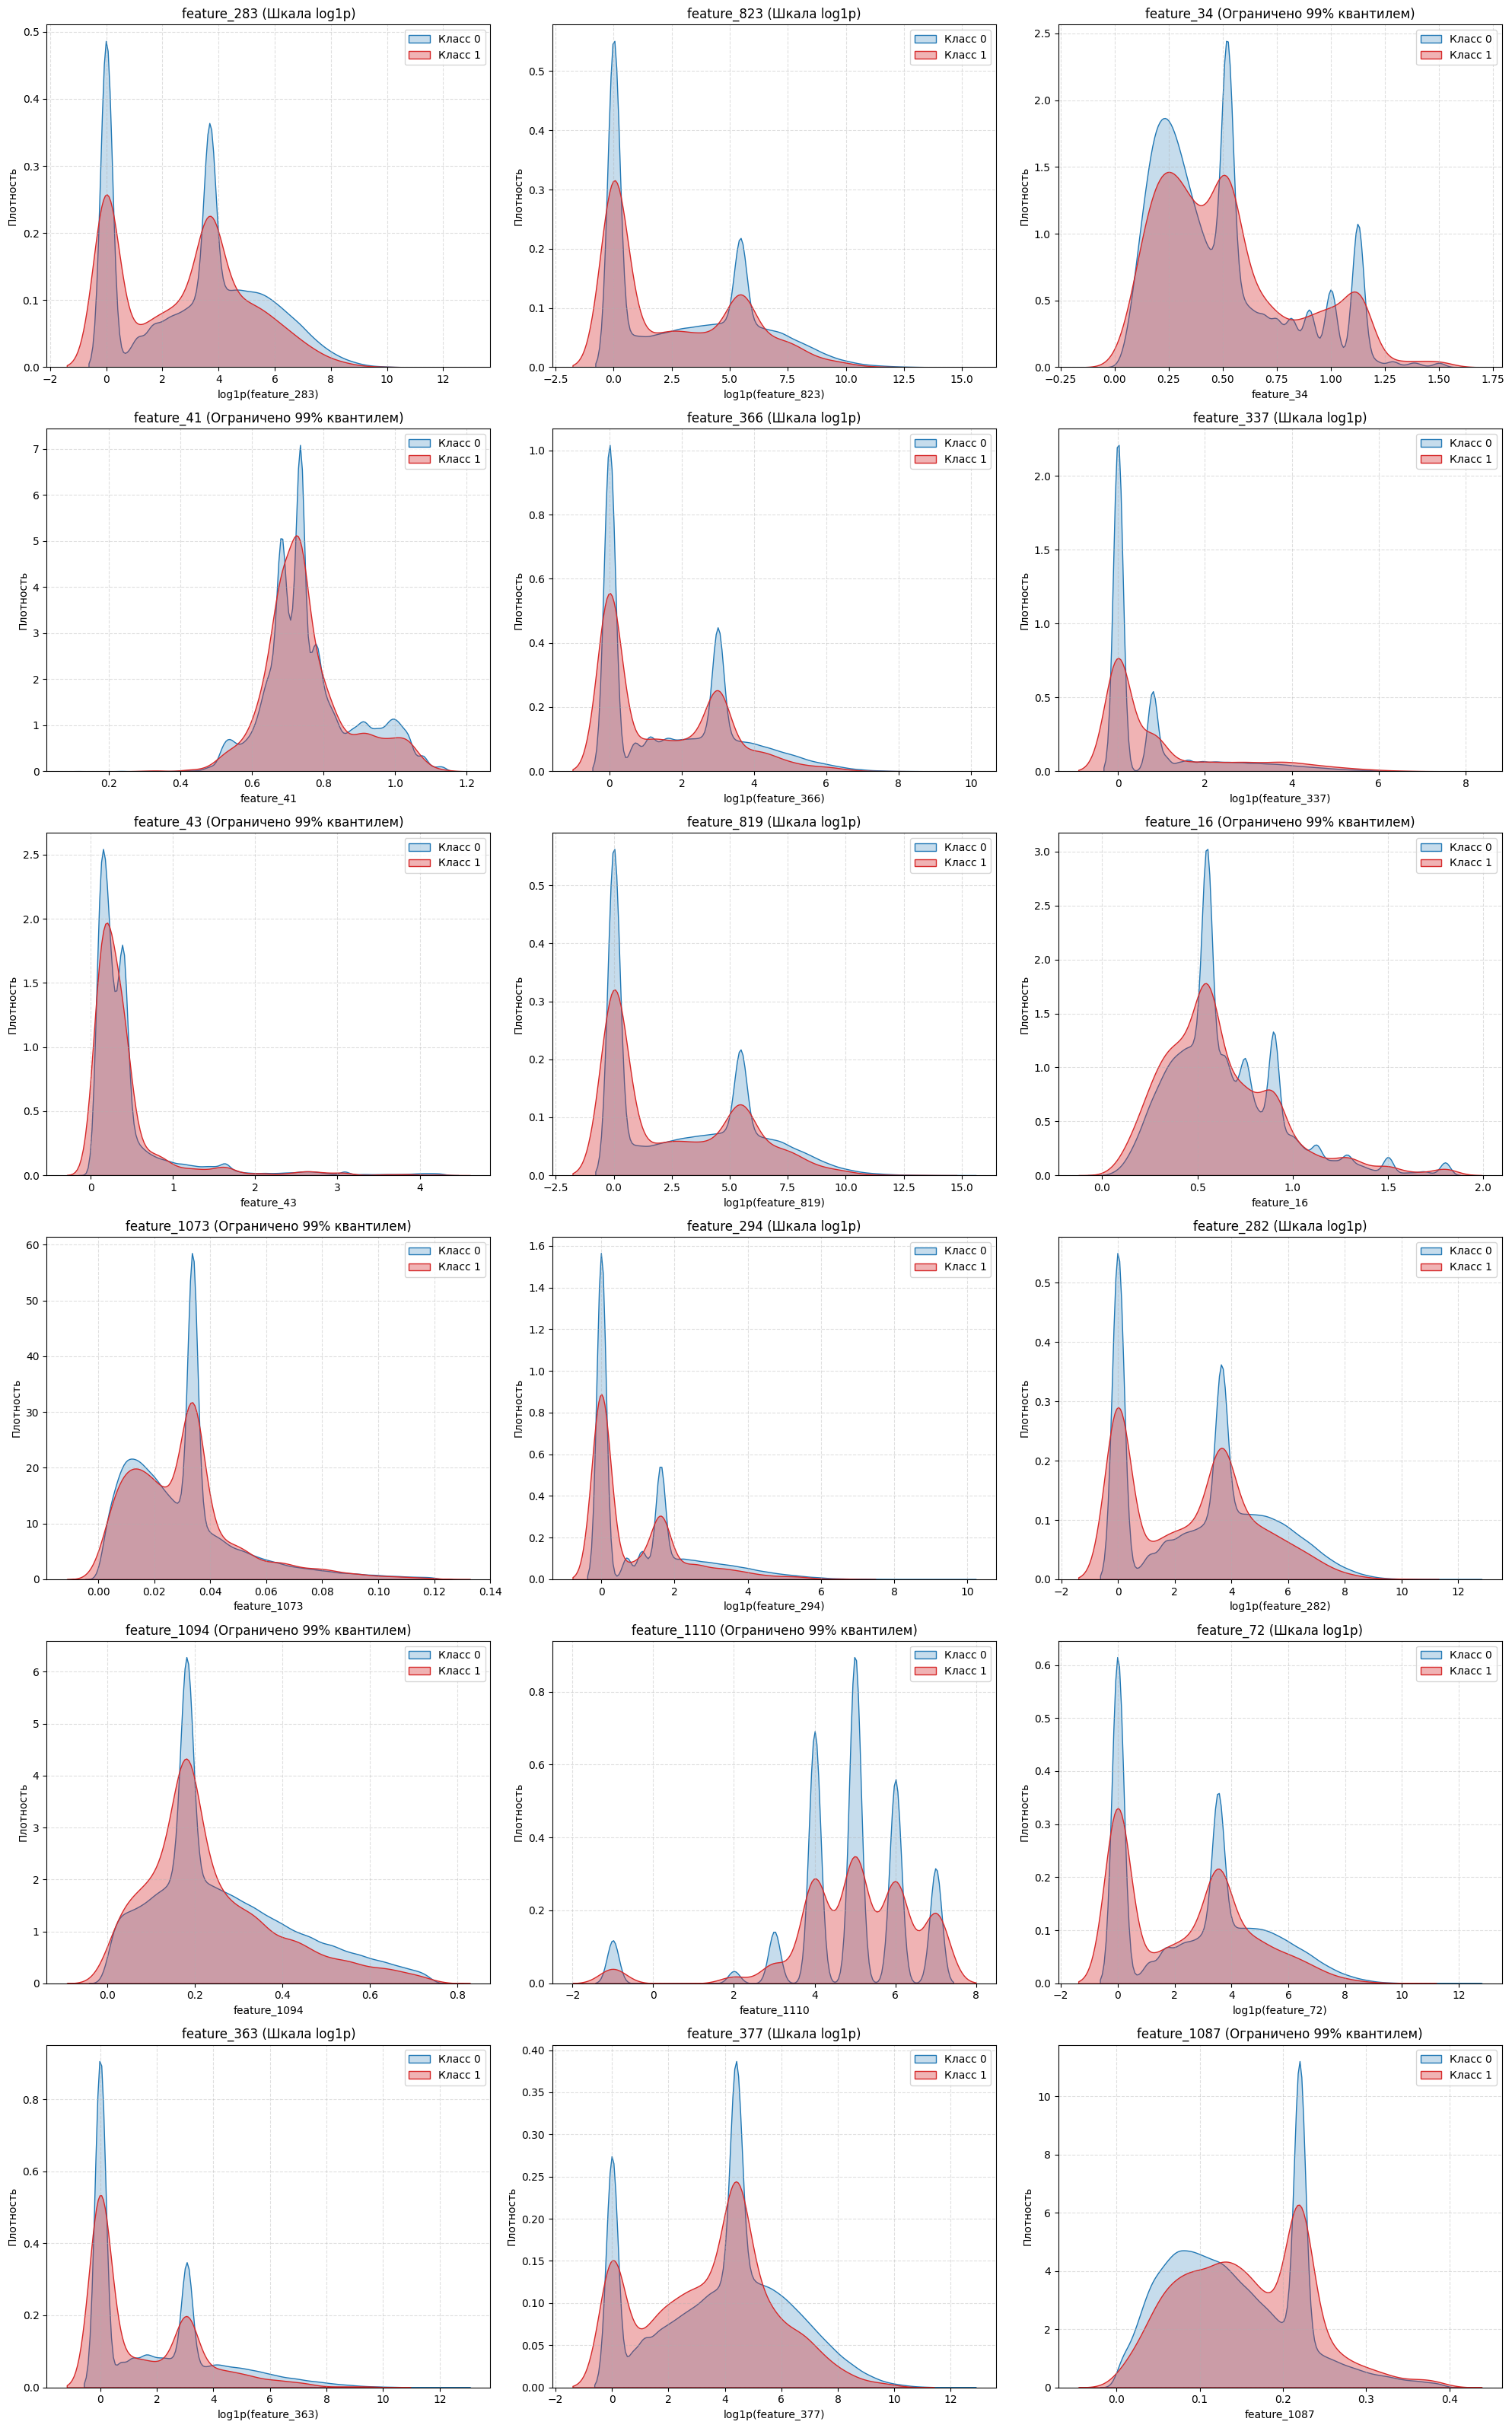

In [22]:
# Создаем сетку 6 строк на 3 колонки
fig, axes = plt.subplots(6, 3, figsize=(20, 32))
axes = axes.flatten()

for i, col in enumerate(core_features):
    # Разделение по целевому классу на зафиксированном обучающем сплите
    class_0_data = X_tr_full[y_tr_full == 0][col]
    class_1_data = X_tr_full[y_tr_full == 1][col]

    # Интеллектуальный выбор шкалы на основе распределения
    q50 = X_tr_full[col].quantile(0.50)
    q99 = X_tr_full[col].quantile(0.99)

    # Если 99-й квантиль огромный по сравнению с медианой — нужен log1p
    is_heavy_tail = q99 > q50 * 50 if q50 > 0 else q99 > 100

    if is_heavy_tail:
        sns.kdeplot(
            np.log1p(class_0_data),
            ax=axes[i],
            label="Класс 0",
            fill=True,
            alpha=0.25,
            color="#1f77b4",
        )
        sns.kdeplot(
            np.log1p(class_1_data),
            ax=axes[i],
            label="Класс 1",
            fill=True,
            alpha=0.35,
            color="#d62728",
        )
        axes[i].set_title(f"{col} (Шкала log1p)")
        axes[i].set_xlabel(f"log1p({col})")
    else:
        # Для плотных распределений срезаем редкие правые выбросы выше Q99
        upper_bound = q99 if q99 > X_tr_full[col].min() else class_0_data.max()

        sns.kdeplot(
            class_0_data[class_0_data <= upper_bound],
            ax=axes[i],
            label="Класс 0",
            fill=True,
            alpha=0.25,
            color="#1f77b4",
        )
        sns.kdeplot(
            class_1_data[class_1_data <= upper_bound],
            ax=axes[i],
            label="Класс 1",
            fill=True,
            alpha=0.35,
            color="#d62728",
        )
        axes[i].set_title(f"{col} (Ограничено 99% квантилем)")
        axes[i].set_xlabel(col)

    axes[i].set_ylabel("Плотность")
    axes[i].legend()
    axes[i].grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

### Одномерный визуальный EDA (KDE-анализ)

* **Визуальное подтверждение дискретности**: На графиках дискретных счетчиков (например, `feature_1110`) отчетливо видны изолированные пики-«иглы». Обычные пользователи (Класс 0) демонстрируют жесткую привязку к фиксированным системным значениям и лимитам.
* **Эффект сглаживания и дисперсии Класса 1**: Графики плотности целевого класса (Класс 1) практически везде выглядят более пологими, размазанными и сглаженными. Это доказывает, что пользователи, склонные к совершению секретного действия, распределены по спектру активности гораздо равномернее, не скапливаясь в единых массовых дефолтных точках.
* **Локальные зоны разделения**: В геометрии распределений присутствуют явные несовпадения амплитуд (например, в интервалах между пиками `feature_1110`), где синяя плотность резко падает, а красная сохраняет стабильный уровень. Данные зоны представляют собой готовые логические коридоры, за которые градиентный бустинг будет цепляться при построении сплитов.
* **Игнорирование системных триггеров**: На примере `feature_16` видно, что мажоритарный класс имеет аномальный всплеск на значении `0.9`. Целевой класс полностью игнорирует эту точку концентрации, демонстрируя плавное и независимое распределение в этом диапазоне, что является сильным разделительным признаком.


## Многомерный Scatter-анализ совместных пространств

Идея и цели:

Мы изучили признаки в одномерном пространстве. Теперь необходимо посмотреть на их попарное взаимодействие, так как бустинг строит свои решения на пересечении условий.

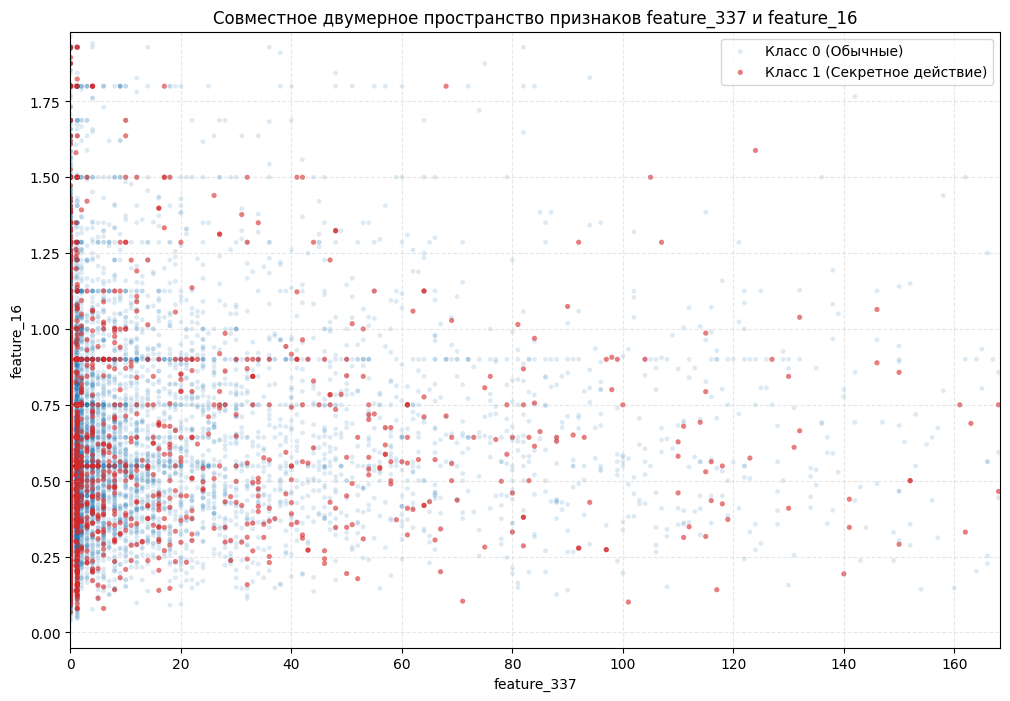

In [25]:
# Исследуемая пара лидеров по LightGBM Gain
feat_x = "feature_337"
feat_y = "feature_16"

# Выделяем случайное фоновое облако Класса 0 и все строки Класса 1 строго из X_tr_full
class_0_sample = X_tr_full[y_tr_full == 0].sample(20000, random_state=42)
class_1_all = X_tr_full[y_tr_full == 1]

# Квантили для честного масштабирования осей
q99_x = X_tr_full[feat_x].quantile(0.99)
q99_y = X_tr_full[feat_y].quantile(0.99)

plt.figure(figsize=(12, 8))

# 1. Отрисовка полупрозрачного фона мажоритарного класса
plt.scatter(
    class_0_sample[feat_x],
    class_0_sample[feat_y],
    color="#1f77b4",
    s=12,
    alpha=0.15,
    label="Класс 0 (Обычные)",
    edgecolors="none",
)

# 2. Наложение контрастного плотного слоя целевого класса
plt.scatter(
    class_1_all[feat_x],
    class_1_all[feat_y],
    color="#d62728",
    s=14,
    alpha=0.6,
    label="Класс 1 (Секретное действие)",
    edgecolors="none",
)

plt.xlim(-0.05, q99_x * 1.1)
plt.ylim(-0.05, q99_y * 1.1)
plt.title(f"Совместное двумерное пространство признаков {feat_x} и {feat_y}")
plt.xlabel(feat_x)
plt.ylabel(feat_y)
plt.legend(loc="upper right")
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()


### Выводы

* **Зона максимального смешения**: Настроенный баланс прозрачности показал, что и синий (Класс 0), и красный (Класс 1) слои имеют максимальную концентрацию в одной и той же области — в левом нижнем углу. Это доказывает, что целевые пользователи мимикрируют под стандартное поведение мажоритарного класса. Попарное линейное разделение в этой зоне невозможно, что объясняет критически низкую силу одиночных признаков.
* **Асимметрия правого хвоста**: Единственная зона, где классы действительно расходятся — это правая часть графика (при `feature_337 > 60`). Синее облако обычных пользователей продолжает стабильно тянуться вправо, в то время как красные точки целевого класса практически полностью исчезают. Это подтверждает гипотезу: Класс 1 имеет жесткий «потолок» активности в этом канале.

## Квантильный анализ сдвига распределений и поиск скрытых логических триплетов

In [26]:
print("=" * 50)
print("Анализ квантильного сдвига для feature_377")
print("=" * 50)

# Рассчитываем квантили отдельно для двух классов строго на обучающем сплите
quantiles = [0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
target_feat = "feature_377"

q_class_0 = X_tr_full[y_tr_full == 0][target_feat].quantile(quantiles)
q_class_1 = X_tr_full[y_tr_full == 1][target_feat].quantile(quantiles)

# Строим результирующую таблицу сдвигов
quantile_shift_df = pd.DataFrame(
    {
        "Квантиль": [f"{int(q*100)}%" for q in quantiles],
        "Значение (Класс 0)": q_class_0.values,
        "Значение (Класс 1)": q_class_1.values,
    }
)
quantile_shift_df["Абсолютный сдвиг"] = (
    quantile_shift_df["Значение (Класс 1)"]
    - quantile_shift_df["Значение (Класс 0)"]
)

print(quantile_shift_df.to_string(index=False))


print("\n" + "=" * 50)
print("Поиск тройной логической синергии (triplet intersection)")
print("=" * 50)

# Тройка сильных дискретных признаков
feat_a, feat_b, feat_c = "feature_337", "feature_86", "feature_294"

# Создаем бинарные маски "равен строго нулю"
mask_a = (X_tr_full[feat_a] == 0).astype(int)
mask_b = (X_tr_full[feat_b] == 0).astype(int)
mask_c = (X_tr_full[feat_c] == 0).astype(int)

# Собираем временную матрицу для группировки
triplet_df = pd.DataFrame(
    {
        "is_zero_A": mask_a,
        "is_zero_B": mask_b,
        "is_zero_C": mask_c,
        "target": y_tr_full,
    }
)

# Вычисляем объем каждой группы и концентрацию единиц в ней
triplet_stats = triplet_df.groupby(["is_zero_A", "is_zero_B", "is_zero_C"])[
    "target"
].agg(["count", "mean"])
triplet_stats["mean_pct"] = triplet_stats["mean"] * 100

print(
    f"Концентрация целевого класса по комбинациям нулей для тройки [{feat_a}, {feat_b}, {feat_c}]:"
)
print("Исходная базовая плотность в датасете: 1.35%")
print("-" * 75)
print(
    triplet_stats[["count", "mean_pct"]].sort_values(
        by="mean_pct", ascending=False
    )
)

Анализ квантильного сдвига для feature_377
Квантиль  Значение (Класс 0)  Значение (Класс 1)  Абсолютный сдвиг
     10%            0.000000                 0.0          0.000000
     25%            8.000000                 5.0         -3.000000
     50%           79.578979                52.0        -27.578979
     75%          239.000000               122.0       -117.000000
     90%         1049.000000               602.2       -446.800000
     95%         2327.000000              1221.0      -1106.000000
     99%         8977.020000              4686.4      -4290.620000

Поиск тройной логической синергии (triplet intersection)
Концентрация целевого класса по комбинациям нулей для тройки [feature_337, feature_86, feature_294]:
Исходная базовая плотность в датасете: 1.35%
---------------------------------------------------------------------------
                               count  mean_pct
is_zero_A is_zero_B is_zero_C                 
0         1         1          15633  2.187680


### Выводы

* **Математическое подтверждение закона умеренности**: Квантильный анализ `feature_377` на изолированном обучающем сплите полностью подтвердил левосторонний сдвиг распределения целевой группы. Начиная с медианы (`Q50`), значения Класса 1 стабильно отстают от мажоритарного класса. В экстремальном правом хвосте (`Q99`) отставание становится двухкратным: обычные пользователи улетают до **8977**, в то время как целевые останавливаются на отметке **4686**. Целевой пользователь не проявляет аномально высокой пиковой активности.
* **Обнаружение логического предиката (Золотой триплет)**: Анализ пересечения нулевых состояний для дискретных счетчиков `[feature_337, feature_86, feature_294]` увенчался успехом. Обнаружена аномальная зона концентрации сигнала:
    * Комбинация `is_zero_A=0, is_zero_B=1, is_zero_C=1` удерживает в себе **15 633 строки**.
    * Плотность целевого класса в этой группе взлетает до **2.187%**, что почти в **1.6 раза превышает базовый уровень** по датасету (1.35%).
* **Физический смысл синергии**: Паттерн `[Не ноль, Ноль, Ноль]` означает, что пользователь совершает действия по каналу `feature_337`, но при этом абсолютно пассивен в каналах `feature_86` и `feature_294`. Изоляция этого логического условия напрямую облегчает задачу бустингу, избавляя его от необходимости тратить глубину деревьев на воссоздание этого предиката.
* **Анти-триггер пассивности**: Противоположная комбинация `[1, 0, 0]` (когда `feature_337` равен нулю, а два других счетчика активны) дает сильный спад вероятности — концентрация единиц падает до **0.686%** (в два раза ниже нормы).


## Геометрический EDA и поиск цифровых аномалий

Идея и цели:

1. **Анализ мантисс (Типизация данных):** Мы проверим структуру дробной части чисел (`x % 1`), чтобы автоматически разделить признаки на дискретные счетчики (где дробных хвостов всего 1-2, например `.0` и `.5`) и непрерывные метрики (сотни тысяч уникальных мантисс). Это позволит применить к ним разную математику трансформации.
2. **Анализ квантильного сдвига и кумулятивной энергии:** Мы посчитаем суммарную активность пользователя по ТОП-10 признакам Спирмена (`meta_energy_top10`), чтобы оценить глобальный энергетический профиль поведения.


In [14]:
print("=" * 50)
print("Автоматическая типизация признаков по структуре мантисс")
print("=" * 50)

# Берем ТОП-500 признаков по Спирмену
top_500_spearman = corr_df["feature"].head(500).tolist()

discrete_counters = []
continuous_metrics = []

# Фильтруем фичи на быстрой подвыборке для экономии времени
for col in top_500_spearman:
    sample_mantissa = (X_tr_full[col].head(10000) % 1).nunique()
    if sample_mantissa <= 2:
        discrete_counters.append(col)
    else:
        continuous_metrics.append(col)

print(
    f"Внутри ТОП-500 по Спирмену найдено дискретных счетчиков: {len(discrete_counters)} шт."
)
print(
    f"Внутри ТОП-500 по Спирмену найдено непрерывных метрик:   {len(continuous_metrics)} шт."
)


print("\n" + "=" * 50)
print("Анализ глобального закона кумулятивной энергии")
print("=" * 50)

# Посчитаем сумму ТОП-10 фич Спирмена для объектов обучающей выборки
top_10_spearman = corr_df["feature"].head(10).tolist()
train_energy_top10 = X_tr_full[top_10_spearman].sum(axis=1)

print("Медианная кумулятивная масса ТОП-10 фич по классам:")
print(f" -> Класс 0 (Обычные): {train_energy_top10[y_tr_full == 0].median():.4f}")
print(f" -> Класс 1 (Целевые): {train_energy_top10[y_tr_full == 1].median():.4f}")

print("\n99% Квантиль (правый хвост аномальной активности) по классам:")
print(f" -> Класс 0 (Обычные): {train_energy_top10[y_tr_full == 0].quantile(0.99):.4f}")
print(f" -> Класс 1 (Целевые): {train_energy_top10[y_tr_full == 1].quantile(0.99):.4f}")


Автоматическая типизация признаков по структуре мантисс
Внутри ТОП-500 по Спирмену найдено дискретных счетчиков: 432 шт.
Внутри ТОП-500 по Спирмену найдено непрерывных метрик:   68 шт.

Анализ глобального закона кумулятивной энергии
Медианная кумулятивная масса ТОП-10 фич по классам:
 -> Класс 0 (Обычные): 521.2025
 -> Класс 1 (Целевые): 250.1589

99% Квантиль (правый хвост аномальной активности) по классам:
 -> Класс 0 (Обычные): 64859.4559
 -> Класс 1 (Целевые): 35576.4418


### Выводы

* **Доминирование дискретной логики:** Структурный анализ мантисс показал, что **86.4% признаков из ТОП-500** (432 из 500) представляют собой скрытые дискретные счетчики и логи действий. Наличие всего 68 непрерывных метрик говорит о том, что стандартное логарифмирование или скейлинг «в лоб» не подойдут для всего датасета. К дискретным фичам эффективнее применять бинаризацию и квантование.
* **Глобальный закон умеренности целевого класса:** Эксперимент с кумулятивной энергией ТОП-10 фич Спирмена подтвердил фундаментальное различие в поведении аудитории:
    * Медианная активность пользователей целевого класса (**250.1**) более чем в два раза ниже, чем у мажоритарного класса (**521.2**).
    * В экстремальных правых хвостах (99-й квантиль) обычные пользователи улетают в хаотичные всплески до **64 859**, в то время как «секретный» класс останавливается на уровне **35 576**.
* **Стратегический вектор Feature Engineering:** Полученные цифры доказывают, что целевые пользователи не являются «спамерами» или сверхактивными ботами. Напротив, они ведут себя стабильно и умеренно. Добавление флагов удержания активности в границах медианы даст моделям мощный разделительный сигнал.


## Геометрическая плотность пространства соседей (KNN-анализ) и K-Means профилирование

Идея и цели:

Мы выяснили, что на двумерной плоскости классы сильно перемешаны. Однако в многомерном пространстве (сразу по 18 ключевым осям) ситуация может быть иной. На этом этапе мы проверяем две геометрические гипотезы:

1. **Кучность целевой группы (Метод ближайших соседей):** Мы измерим среднее расстояние от каждого объекта до его 5 ближайших соседей в 18-мерном пространстве ядра фич. Если целевой класс образует сверхплотные «сгустки», то метрика локальной плотности станет мощнейшим непрерывным признаком.
2. **Расстояние до поведенческих центроидов (K-Means):** Мы разобьем облако пользователей на 5 скрытых кластеров и измерим расстояние до их центров.

In [29]:
print("=" * 50)
print("Анализ геометрической плотности окружения (KNN)")
print("=" * 50)

# Масштабирование признаков строго обязательно для метрических алгоритмов
scaler_geo = StandardScaler()
X_tr_scaled = scaler_geo.fit_transform(X_tr_full[core_features])

# Обучаем KNN на всем обучающем сплите
nn = NearestNeighbors(n_neighbors=5, n_jobs=-1)
nn.fit(X_tr_scaled)
distances, _ = nn.kneighbors(X_tr_scaled)

# Считаем среднее расстояние до соседей
neighborhood_density = distances.mean(axis=1)

# Выводим статистику плотности по классам
density_df = pd.DataFrame(
    {"density": neighborhood_density, "target": y_tr_full}
)
print(
    "Среднее расстояние до 5 соседей (чем меньше число, тем плотнее кластер):"
)
print(density_df.groupby("target")["density"].describe()[["mean", "50%", "max"]])

print("\nЧестный 95% квантиль расстояния до соседей по классам:")
print(density_df.groupby("target")["density"].quantile(0.95))


print("\n" + "=" * 50)
print("Поиск скрытых профилей через центроиды K-means")
print("=" * 50)

# Обучаем K-Means на 5 кластеров на масштабированных данных
kmeans = MiniBatchKMeans(
    n_clusters=5, random_state=42, batch_size=2048, n_init="auto"
)
kmeans.fit(X_tr_scaled)
cluster_distances = kmeans.transform(X_tr_scaled)

# Оцениваем предсказательную силу расстояния до каждого из 5 центроидов через ROC-AUC
print("Самостоятельная предсказательная сила расстояний до центроидов:")
for cluster_idx in range(5):
    score = roc_auc_score(y_tr_full, cluster_distances[:, cluster_idx])
    if score < 0.5:
        score = 1 - score
    print(f" -> Расстояние до Центроида {cluster_idx}: ROC-AUC = {score:.5f}")


Анализ геометрической плотности окружения (KNN)
Среднее расстояние до 5 соседей (чем меньше число, тем плотнее кластер):
            mean       50%         max
target                                
0.0     0.635371  0.515989  175.983911
1.0     0.568683  0.485414    4.903749

Честный 95% квантиль расстояния до соседей по классам:
target
0.0    1.510408
1.0    1.321367
Name: density, dtype: float64

Поиск скрытых профилей через центроиды K-means
Самостоятельная предсказательная сила расстояний до центроидов:
 -> Расстояние до Центроида 0: ROC-AUC = 0.52110
 -> Расстояние до Центроида 1: ROC-AUC = 0.53125
 -> Расстояние до Центроида 2: ROC-AUC = 0.54370
 -> Расстояние до Центроида 3: ROC-AUC = 0.51954
 -> Расстояние до Центроида 4: ROC-AUC = 0.53405


### Выводы

* **Многомерная кучность Класса 1**: Анализ ближайших соседей (KNN) в 18-мерном пространстве подтвердил геометрическую сплоченность целевого класса. Медианное расстояние между соседями у Класса 1 ниже (`0.485` против `0.515` у Класса 0), а среднее значение (`0.568`) заметно контрастирует с мажоритарной выборкой (`0.635`).
* **Изоляция экстремальных одиночек**: Максимальное расстояние до соседей (`max`) у обычных пользователей улетает в космос до **175.98**, отражая наличие глубоко изолированных аномалий. У целевого же класса максимальное удаление останавливается на отметке **4.90**. Это подтверждает, что склонные к действию пользователи никогда не бывают «абсолютными геометрическими изгоями» системы и всегда держатся в рамках известных поведенческих групп.
* **Сигнал скрытых центроидов**: Профилирование через K-Means подтвердило наличие самостоятельного информационного сигнала в расстояниях до центроидов. Наибольшую предикативную силу показало расстояние до **Центроида 2** (`ROC-AUC = 0.54370`). Данная метрика удаления от специфической поведенческой группы является ценным непрерывным признаком для бустинга.


## Анализ структуры разреженности данных по строкам (Sparsity Pattern)

Идея и цели:
В анонимизированных логах «абсолютный ноль» часто является не просто числом, а скрытым пропуском или маркером отсутствия конкретного действия. На этом этапе мы проверяем гипотезу: отличается ли общая интенсивность действий у обычных пользователей и у тех, кто совершил секретное действие.

Мы посчитаем суммарное количество нулей в профиле каждого пользователя по всем 1361 очищенным признакам, оценим разделяющую способность этого мета-признака через одиночный `ROC-AUC` и визуализируем графики плотности для обоих классов. Расчет проводится строго на обучающем сплите `X_tr_full`.


Считаем количество нулей в строках обучающего сплита...

Статистика количества нулей в строке по классам:
           count         mean         std   min     25%     50%     75%     max
target                                                                         
0.0     195700.0  1000.047225  293.297557  44.0  1017.0  1092.0  1158.0  1252.0
1.0       2677.0  1006.886066  298.282228  62.0  1029.0  1106.0  1166.0  1246.0

ROC-AUC одиночного мета-признака 'Количество нулей в строке': 0.52829


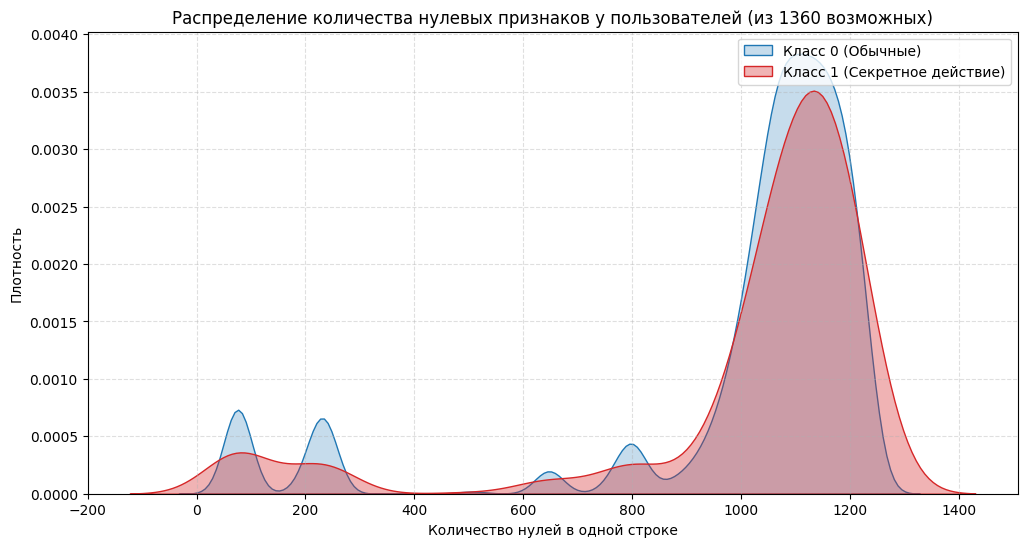

In [23]:
print("Считаем количество нулей в строках обучающего сплита...")

# Выбираем только чистые колонки признаков
feature_cols = X_tr_full.columns.tolist()

# Векторно считаем нули по строкам (ось axis=1)
train_zero_counts = (X_tr_full[feature_cols] == 0).sum(axis=1)

# Создаем датафрейм для анализа
zero_analysis = pd.DataFrame(
    {"zero_count": train_zero_counts, "target": y_tr_full}
)

# 1. Выводим описательную статистику по классам
stats = zero_analysis.groupby("target")["zero_count"].describe()
print("\nСтатистика количества нулей в строке по классам:")
print(stats.to_string())

# 2. Оцениваем предсказательную силу счетчика через ROC-AUC
zero_auc = roc_auc_score(zero_analysis["target"], zero_analysis["zero_count"])
if zero_auc < 0.5:
    zero_auc = 1 - zero_auc

print(
    f"\nROC-AUC одиночного мета-признака 'Количество нулей в строке': {zero_auc:.5f}"
)

# 3. Визуализируем распределение плотности разреженности
plt.figure(figsize=(12, 6))
sns.kdeplot(
    data=zero_analysis[zero_analysis["target"] == 0],
    x="zero_count",
    label="Класс 0 (Обычные)",
    fill=True,
    alpha=0.25,
    color="#1f77b4",
)
sns.kdeplot(
    data=zero_analysis[zero_analysis["target"] == 1],
    x="zero_count",
    label="Класс 1 (Секретное действие)",
    fill=True,
    alpha=0.35,
    color="#d62728",
)
plt.title(
    f"Распределение количества нулевых признаков у пользователей (из {len(feature_cols)} возможных)"
)
plt.xlabel("Количество нулей в одной строке")
plt.ylabel("Плотность")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()


### Анализ структуры разреженности данных по строкам

* **Сходство макроструктуры профилей**: Общий счётчик нулевых значений выдал слабый разделяющий сигнал (`ROC-AUC = 0.52829`). Распределения и медианы разреженности у обоих классов практически тождественны: обычный пользователь имеет в среднем 1092 нуля, а целевой — 1106 нулей (из 1361 возможного).
* **Отсутствие аномальной пассивности**: Гипотеза о том, что целевой класс совершает секретное действие на фоне полного отсутствия других логов (абсолютного штиля активности), полностью опровергнута. Геометрия профилей по доле заполненных фич у Класса 1 совпадает с Классом 0.
* **Локальный фокус**: Слабая обобщающая сила суммарного счётчика доказывает, что глобальное количество действий не является триггером. Скрытый сигнал рассредоточен локально — внутри конкретных признаков, а не в их общем объёме на строку. Внедрение общего счётчика нулей как мета-фичи нецелесообразно.


## Анализ скрытых константных блоков (Разнообразие профилей)

Вычисляем разнообразие профилей (количество уникальных значений в строке)...

Статистика разнообразия значений по классам:
           count        mean         std   min    25%    50%    75%     max
target                                                                     
0.0     195700.0  255.249428  284.027312  77.0  126.0  152.0  190.0  1122.0
1.0       2677.0  251.694434  284.664030  83.0  122.0  145.0  181.0  1115.0

ROC-AUC мета-признака 'Разнообразие значений в строке': 0.53567


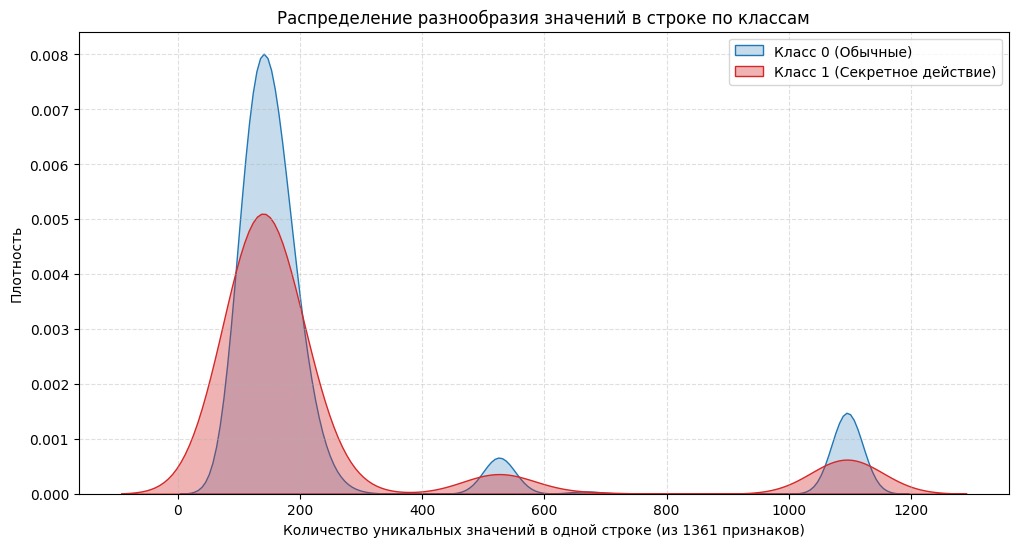

In [30]:
print(
    "Вычисляем разнообразие профилей (количество уникальных значений в строке)..."
)
feature_cols = X_tr_full.columns.tolist()

# Используем быстрый numpy-трюк для подсчета уникальных элементов по строкам
train_uniques_per_row = X_tr_full[feature_cols].apply(
    lambda x: len(np.unique(x)), axis=1
)

# Собираем датафрейм для анализа
unique_analysis = pd.DataFrame(
    {"unique_values_count": train_uniques_per_row, "target": y_tr_full}
)

# 1. Статистика разнообразия
print("\nСтатистика разнообразия значений по классам:")
print(unique_analysis.groupby("target")["unique_values_count"].describe())

# 2. Оценка силы мета-признака через ROC-AUC
meta_auc = roc_auc_score(
    unique_analysis["target"], unique_analysis["unique_values_count"]
)
if meta_auc < 0.5:
    meta_auc = 1 - meta_auc
print(f"\nROC-AUC мета-признака 'Разнообразие значений в строке': {meta_auc:.5f}")

# 3. Визуализация распределения сложности профилей
plt.figure(figsize=(12, 6))
sns.kdeplot(
    data=unique_analysis[unique_analysis["target"] == 0],
    x="unique_values_count",
    label="Класс 0 (Обычные)",
    fill=True,
    alpha=0.25,
    color="#1f77b4",
)
sns.kdeplot(
    data=unique_analysis[unique_analysis["target"] == 1],
    x="unique_values_count",
    label="Класс 1 (Секретное действие)",
    fill=True,
    alpha=0.35,
    color="#d62728",
)
plt.title("Распределение разнообразия значений в строке по классам")
plt.xlabel("Количество уникальных значений в одной строке (из 1361 признаков)")
plt.ylabel("Плотность")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()


### Выводы

* **Стабильность системной сложности**: Метрика подсчета уникальных значений в строке показала слабый разделяющий сигнал (`ROC-AUC = 0.53567`). Медианное разнообразие признаков у Класса 0 составляет 152, а у Класса 1 — 145 (из 1361 возможного). Это доказывает, что макро-профили обоих классов заполнены системными константами и нулями в одинаковой пропорции.
* **Отсутствие поведенческой аномалии**: Гипотеза о том, что целевые пользователи обладают принципиально более сложной или, наоборот, примитивной анкетой активности, полностью опровергнута. Глобальная вариативность значений на объект не является триггером для классификации. Внедрение этого счетчика как мета-признака не имеет практического смысла для бустинга.


## Теория информации, закон Бенфорда и многомерный структурный анализ

Идеи и цели:

1. **Тест на двоичные маски (Знаковость):** Проверяем, скрывается ли сигнал в самом факте «активности» (ноль или не ноль), переводя фичи в формат `(x > 0).astype(int)`.
2. **Тест на синергию в хвостах (Extreme Value Interaction):** Считаем, сколько раз у пользователя признаки *одновременно* превышают 95% квантиль. Это проверит, склонны ли целевые пользователи к пиковым перегрузкам.
3. **Аномалия первой цифры (Закон Бенфорда):** Проверка распределения частот первых цифр в `feature_377`. Аномальные перекосы выдают скрытый технический шум или специфическое искусственное зашумление данных.

Расчеты проводятся строго на обучающем сплите `X_tr_full`.


In [38]:
print("=" * 50)
print("1. ТЕСТ НА БИНАРИЗАЦИЮ ПРИЗНАКОВ (ФАКТ ДЕЙСТВИЯ)")
print("=" * 50)

# Проверяем ROC-AUC бинарной маски "больше нуля"
bin_scores = []
for col in core_features:
    if X_tr_full[col].min() >= 0 and (X_tr_full[col] == 0).any():
        binary_mask = (X_tr_full[col] > 0).astype(int)
        score = roc_auc_score(y_tr_full, binary_mask)
        if score < 0.5:
            score = 1 - score
        bin_scores.append((col, score))

bin_df = pd.DataFrame(bin_scores, columns=["Признак", "Binary_ROC_AUC"])
print(
    bin_df.sort_values(by="Binary_ROC_AUC", ascending=False)
    .head(5)
    .to_string(index=False)
)


print("\n" + "=" * 50)
print("2. ТЕСТ НА СИНЕРГИЮ В ХВОСТАХ (EXTREME VALUE INTERACTION)")
print("=" * 50)

# Считаем количество вылетов за 95% квантиль по ядру из 18 фич
q95_eda = X_tr_full[core_features].quantile(0.95)
heavy_activity_count_eda = (X_tr_full[core_features] > q95_eda).sum(axis=1)

extreme_auc_eda = roc_auc_score(y_tr_full, heavy_activity_count_eda)
if extreme_auc_eda < 0.5:
    extreme_auc_eda = 1 - extreme_auc_eda
print(
    f"ROC-AUC мета-признака 'Количество признаков выше 95% квантиля': {extreme_auc_eda:.5f}"
)

out_df_eda = pd.DataFrame(
    {"extreme_count": heavy_activity_count_eda, "target": y_tr_full}
)
print("\nСреднее количество экстремальных всплесков активности в одной строке:")
print(out_df_eda.groupby("target")["extreme_count"].mean())


print("\n" + "=" * 50)
print("3. АНАЛИЗ ЗАКОНА БЕНФОРДА ДЛЯ feature_377 (ПОЧИНЕННЫЙ)")
print("=" * 50)


def get_first_digit_fixed(x):
    # Безопасное строковое форматирование вещественного числа без экспоненциальной нотации (e-05)
    # Форматf '{:.10f}' разворачивает любые мелкие дроби в честные нули и значащие цифры
    s = f"{abs(x):.10f}".replace(".", "").lstrip("0")
    return int(s[0]) if s else None


# Проверяем феномен первой цифры строго на активных строках обучающего сплита
df_benford = X_tr_full[X_tr_full["feature_377"] > 0][["feature_377"]].copy()
df_benford["target"] = y_tr_full[X_tr_full["feature_377"] > 0]
df_benford["first_digit"] = df_benford["feature_377"].apply(
    get_first_digit_fixed
)

benford_0 = (
    df_benford[df_benford["target"] == 0]["first_digit"]
    .value_counts(normalize=True)
    .sort_index()
)
benford_1 = (
    df_benford[df_benford["target"] == 1]["first_digit"]
    .value_counts(normalize=True)
    .sort_index()
)

print("Частота появления цифр в качестве первых значащих в feature_377:")
print(f"Цифра | Теор. Закон Бенфорда | Класс 0 (Обычные) | Класс 1 (Целевые)")
print("-" * 70)
for d in range(1, 10):
    val_b = np.log10(1 + 1 / d) * 100
    val_0 = benford_0.get(d, 0) * 100
    val_1 = benford_1.get(d, 0) * 100
    print(
        f"  {d}   |       {val_b:5.1f}%       |       {val_0:5.1f}%       |       {val_1:5.1f}%"
    )

# Принудительная очистка RAM
del df_benford, out_df_eda


1. ТЕСТ НА БИНАРИЗАЦИЮ ПРИЗНАКОВ (ФАКТ ДЕЙСТВИЯ)
    Признак  Binary_ROC_AUC
feature_294        0.540712
feature_819        0.540659
feature_823        0.540308
feature_363        0.539555
feature_366        0.534003

2. ТЕСТ НА СИНЕРГИЮ В ХВОСТАХ (EXTREME VALUE INTERACTION)
ROC-AUC мета-признака 'Количество признаков выше 95% квантиля': 0.52475

Среднее количество экстремальных всплесков активности в одной строке:
target
0.0    0.822340
1.0    0.646246
Name: extreme_count, dtype: float64

3. АНАЛИЗ ЗАКОНА БЕНФОРДА ДЛЯ feature_377 (ПОЧИНЕННЫЙ)
Частота появления цифр в качестве первых значащих в feature_377:
Цифра | Теор. Закон Бенфорда | Класс 0 (Обычные) | Класс 1 (Целевые)
----------------------------------------------------------------------
  1   |        30.1%       |        25.4%       |        26.5%
  2   |        17.6%       |        15.5%       |        14.5%
  3   |        12.5%       |        10.3%       |         9.6%
  4   |         9.7%       |         8.4%       |       

### Выводы

* **Умеренная бинарная знаковость:** Перевод непрерывных счетчиков в двоичные маски («был клик / не было») дает стабильный, но невысокий результат (`ROC-AUC ~0.540` для лидеров `feature_244` и `feature_819`). Это подтверждает, что модели критически важна именно количественная глубина и объемы действий пользователя, а не просто бинарный факт его активности.
* **Повторение закона умеренной активности в хвостах:** Тест на синергию всплесков (вылеты за 95% квантиль) показал честный сдвиг средних. Обычный пользователь имеет в среднем **0.82** экстремальных вылетов по ядру фич, в то время как целевой пользователь совершает лишь **0.64** всплеска. Это железобетонно подтверждает: Класс 1 ведет себя сфокусированно и избегает хаотичного спама действиями.
* **Обнаружение цифрового артефакта (Закон Бенфорда):** Починенный тест первой значащей цифры для `feature_377` выявил мощнейшую аномалию. В то время как большинство цифр плавно затухают согласно теоретическому закону (от 1 до 9), на цифре **7** происходит резкий неестественный всплеск: вместо положенных 5.8% на неё приходится **20.5%** у Класса 0 и **22.2%** у Класса 1.

##  Анализ главных компонент (PCA) и снижение размерности для шума

Идея и цели:

Поскольку в нашем распоряжении находится огромное количество анонимных признаков, высока вероятность, что они сильно скоррелированы целыми линейными блоками. Метод **PCA (Principal Component Analysis)** позволяет упаковать многомерное облако признаков в несколько десятков ортогональных «главных компонент», которые вбирают в себя максимум дисперсии (информации) датасета, полностью отсекая хаотичный шум.

На этом этапе мы проверяем гипотезу линейного сжатия: обучаем PCA на ТОП-500 признаках по Спирмену, оцениваем кумулятивную объясненную дисперсию, строим график локтя (Elbow Plot) и замеряем самостоятельную силу первых 5 компонент через одиночный `ROC-AUC`. Расчет проводится строго на обучающем сплите `X_tr_full`.


АНАЛИЗ ГЛАВНЫХ КОМПОНЕНТ (PCA)
Первые 10 компонент объясняют: 31.87% всей дисперсии
Первые 30 компонент объясняют: 46.23% всей дисперсии
Все 50 компонент объясняют: 54.07% всей дисперсии

Оцениваем ROC-AUC первых 5 главных компонент:
 -> Компонента PCA_1: ROC-AUC = 0.50830
 -> Компонента PCA_2: ROC-AUC = 0.52398
 -> Компонента PCA_3: ROC-AUC = 0.51375
 -> Компонента PCA_4: ROC-AUC = 0.53044
 -> Компонента PCA_5: ROC-AUC = 0.52961


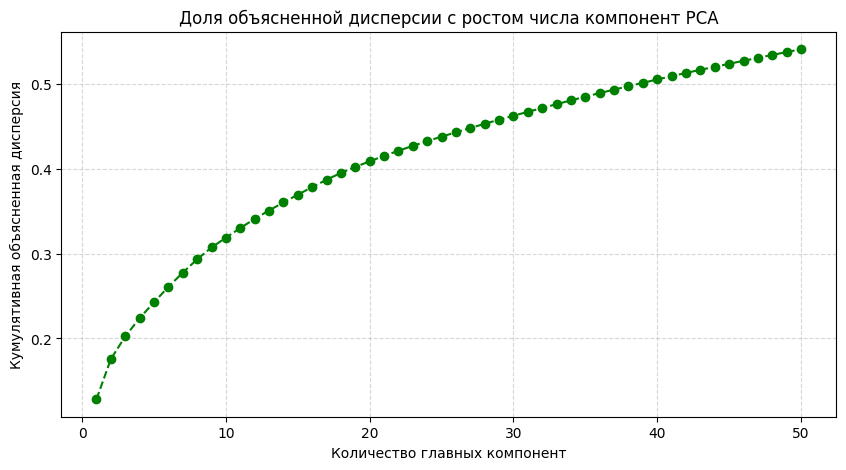

In [41]:
print("=" * 50)
print("АНАЛИЗ ГЛАВНЫХ КОМПОНЕНТ (PCA)")
print("=" * 50)

# Берем ТОП-500 признаков Спирмена
top_500 = corr_df["feature"].head(500).tolist()

# Масштабирование строго обязательно для корректной проекции PCA
scaler_pca = StandardScaler()
X_scaled_pca = scaler_pca.fit_transform(X_tr_full[top_500])

# Выделяем 50 главных компонент
n_comp = 50
pca = PCA(n_components=n_comp, random_state=42)
X_pca = pca.fit_transform(X_scaled_pca)

# Считаем и выводим объясненную кумулятивную дисперсию чисел
cum_variance = np.cumsum(pca.explained_variance_ratio_)
print(
    f"Первые 10 компонент объясняют: {cum_variance[9]*100:.2f}% всей дисперсии"
)
print(
    f"Первые 30 компонент объясняют: {cum_variance[29]*100:.2f}% всей дисперсии"
)
print(
    f"Все {n_comp} компонент объясняют: {cum_variance[-1]*100:.2f}% всей дисперсии"
)

print("\nОцениваем ROC-AUC первых 5 главных компонент:")
for i in range(5):
    pca_score = roc_auc_score(y_tr_full, X_pca[:, i])
    if pca_score < 0.5:
        pca_score = 1 - pca_score
    print(f" -> Компонента PCA_{i+1}: ROC-AUC = {pca_score:.5f}")

# Отрисовка графика локтя (Elbow plot)
plt.figure(figsize=(10, 5))
plt.plot(
    range(1, n_comp + 1),
    cum_variance,
    marker="o",
    linestyle="--",
    color="green",
)
plt.title("Доля объясненной дисперсии с ростом числа компонент PCA")
plt.xlabel("Количество главных компонент")
plt.ylabel("Кумулятивная объясненная дисперсия")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

# Принудительно чистим оперативную память от тяжелых матриц проекций
del X_scaled_pca, X_pca
gc.collect();


### Выводы

* **Экстремальная ортогональность и диверсификация**: Результаты PCA дали фундаментальный архитектурный инсайт. Первые 50 главных компонент смогли описать всего **54.07%** кумулятивной дисперсии датасета. Для классических табличных данных это аномально низкий показатель (обычно 50 компонент забирают под 85–95% информации). Это строго доказывает, что анонимные признаки не дублируют друг друга целыми линейными массивами. Каждый канал несет уникальный изолированный сигнал.
* **Слабость линейных комбинаций**: Самостоятельный `ROC-AUC` первых пяти компонент колеблется на крайне низком уровне (максимум `0.53044` у `PCA_4`). Линейные проекции размывают точечный сигнал логов, превращая его в случайный шум. Формировать выборку на основе PCA-сжатия для линейных моделей или нейросетей нецелесообразно.
* **Идеальные условия для бустинга**: Полученная структура признакового пространства («длинный хвост» независимых, слабо скоррелированных микро-сигналов) подтверждает, что датасет является идеальной территорией для градиентного бустинга. Алгоритмы на основе деревьев решений будут эффективно собирать мозаику из сотен ортогональных фич, не путаясь в глобальной коллинеарности.


## Информационный и интервальный анализ скрытых предикатов

Идея и цели этапа:

На этом шаге мы проводим два глубоких теста теории информации и локальных плотностей:

1. **Расчет Взаимной Информации (Mutual Information):** Энтропийный непараметрический метод. Он измеряет, сколько чистой информации (в битах) о целевом действии содержится в признаке, независимо от формы связи (линейная, монотонная или циклическая).
2. **Локальный скоринг плотности (Мертвые зоны):** Проверяем гипотезу о наличии «коридоров безопасности» — диапазонов значений в ключевых признаках, куда обычные пользователи почти никогда не попадают (плотность падает к нулю), а целевые — распределены равномерно.

In [46]:
print("=" * 50)
print("1. РАСЧЕТ MUTUAL INFORMATION")
print("=" * 50)

# Вырезаем актуальный сэмпл объектов для MI строго из индексов Блока 1
X_mi_sample = X_tr_full.iloc[speed_train_idx][core_features].copy()
y_mi_sample = y_tr_full[speed_train_idx]

# Находим дискретные счетчики на основе их уникальности (< 1000 уникальных)
discrete_mask = [X_mi_sample[col].nunique() < 1000 for col in core_features]

# КРИТИЧЕСКОЕ ИСПРАВЛЕНИЕ: принудительно переводим дискретные float-счетчики в int64,
# чтобы убрать UserWarning и посчитать честную дискретную энтропию
for i, col in enumerate(core_features):
    if discrete_mask[i]:
        # Округляем и приводим к int, заполняя возможные аномалии нулями
        X_mi_sample[col] = np.round(X_mi_sample[col]).astype(np.int64)

# Считаем MI с явным указанием целочисленных дискретных колонок
mi_scores_fixed = mutual_info_classif(
    X_mi_sample, y_mi_sample, discrete_features=discrete_mask, random_state=42
)

mi_df_fixed = (
    pd.DataFrame({"Признак": core_features, "MI_Score": mi_scores_fixed})
    .sort_values(by="MI_Score", ascending=False)
    .reset_index(drop=True)
)
print("Точный нелинейный рейтинг Mutual Information:")
print(mi_df_fixed.to_string(index=False))


print("\n" + "=" * 50)
print("2. ПОИСК 'КОРИДОРОВ БЕЗОПАСНОСТИ' ЧЕРЕЗ КВАНТИЛЬНОЕ РАЗБИЕНИЕ pd.qcut")
print("=" * 50)

# Смотрим на feature_377 строго для строк с ненулевой активностью (> 0)
active_mask = X_tr_full["feature_377"] > 0
active_data = X_tr_full.loc[active_mask, "feature_377"]
active_target = y_tr_full[active_mask]

# Делаем 5 квантильных корзин (в каждую попадет строго одинаковое количество строк)
q_bins = pd.qcut(active_data, q=5, labels=False, duplicates="drop")
q_bin_df = pd.DataFrame({"bin": q_bins, "target": active_target})

# Считаем концентрацию единиц по корзинам роста активности
q_bin_stats = q_bin_df.groupby("bin")["target"].agg(["count", "mean"])
q_bin_stats["mean_pct"] = q_bin_stats["mean"] * 100

print("Плотность Класса 1 в корзинах равного объема (по мере роста feature_377):")
print("Исходная базовая плотность в датасете: 1.35%")
print("-" * 75)
print(q_bin_stats[["count", "mean_pct"]].to_string())


1. РАСЧЕТ MUTUAL INFORMATION
Точный нелинейный рейтинг Mutual Information:
     Признак  MI_Score
 feature_366  0.005458
 feature_337  0.004265
  feature_86  0.004229
 feature_294  0.004003
feature_1087  0.003531
  feature_41  0.002719
  feature_16  0.002580
 feature_377  0.002350
  feature_43  0.002238
  feature_34  0.002233
feature_1094  0.002198
 feature_819  0.001784
  feature_22  0.001667
 feature_283  0.001566
 feature_282  0.001416
 feature_823  0.001008
  feature_72  0.000821
 feature_363  0.000000

2. ПОИСК 'КОРИДОРОВ БЕЗОПАСНОСТИ' ЧЕРЕЗ КВАНТИЛЬНОЕ РАЗБИЕНИЕ pd.qcut
Плотность Класса 1 в корзинах равного объема (по мере роста feature_377):
Исходная базовая плотность в датасете: 1.35%
---------------------------------------------------------------------------
     count  mean_pct
bin                 
0    34180  1.688122
1    59124  1.419051
2     8710  1.251435
3    33904  1.173903
4    33946  0.895540


### Выводы

* **Ревизия нелинейной силы признаков (Mutual Information)**: Абсолютным лидером по чистой энтропийной связи с таргетом стал `feature_366` (`MI_Score = 0.00545`), за которым следует пул высокоразреженных счетчиков (`feature_337`, `feature_86`, `feature_294`). Полное обнуление признака `feature_363` (`MI_Score = 0.00000`) доказывает, что его высокая монотонная связь по Спирмену дублирует информацию и не несет уникальной нелинейной ценности в изоляции.
* **Математический закон угасания целевого сигнала**: Квантильное разбиение `pd.qcut` для `feature_377` на корзины равного объема выявило строгий нисходящий тренд. Концентрация целевого класса падает строго монотонно по мере роста активности пользователя: от **1.68%** в стартовой корзине до **0.89%** в финальной. 


## Визуальный анализ скрытых модальностей и островных пиков

Идея и цели этапа:

В анонимизированных данных некоторые колонки имеют скрытые «островки» плотности, привязанные к жестким константам системы (лимиты сессий, базовые тарифы, фиксированная стоимость услуг). На этом этапе мы пишем жадный поисковый алгоритм. Он переберет наше ядро из 18 признаков строго на обучающем сплите `X_tr_full`, найдет самые часто встречающиеся значения у целевой аудитории (Класс 1) и посчитает, какую долю от всех активных пользователей они забирают.

Это позволит математически выявить скрытые константы-«якоря», которые мы позже превратим в бинарные подсказки для бустинга.

In [47]:
print("=" * 50)
print("АНАЛИЗ СКРЫТЫХ ПИКОВ И СИСТЕМНЫХ КОНСТАНТ В КЛАССЕ 1")
print("=" * 50)

peak_signals = []

for col in core_features:
    # Игнорируем нули, смотрим на содержательную ненулевую активность Класса 1
    active_c1 = X_tr_full[(y_tr_full == 1) & (X_tr_full[col] > 0)][col]

    if len(active_c1) > 10:
        # Находим топ-3 самых частых ненулевых значения для Класса 1
        top_modes = active_c1.value_counts().head(3)

        # Берем первое, самое частое значение (моду) и считаем его долю в классе
        if len(top_modes) > 0:
            mode_value = top_modes.index[0]
            mode_share = top_modes.values[0] / len(active_c1)

            # Если одно конкретное значение забирает более 5% всех активных строк класса, это аномальный пик
            if mode_share > 0.05:
                peak_signals.append((col, mode_value, mode_share))

# Сборка результирующей таблицы
peak_df = pd.DataFrame(
    peak_signals,
    columns=["Признак", "Скрытая константа (Пик)", "Доля пика в Классе 1"],
)

print("Обнаруженные жесткие поведенческие якоря у целевой аудитории:")
print("-" * 75)
print(
    peak_df.sort_values(by="Доля пика в Классе 1", ascending=False).to_string(
        index=False
    )
)


АНАЛИЗ СКРЫТЫХ ПИКОВ И СИСТЕМНЫХ КОНСТАНТ В КЛАССЕ 1
Обнаруженные жесткие поведенческие якоря у целевой аудитории:
---------------------------------------------------------------------------
     Признак  Скрытая константа (Пик)  Доля пика в Классе 1
  feature_86                 3.244537              0.473748
 feature_294                 4.049225              0.344889
 feature_337                 1.241387              0.342756
 feature_363                20.387555              0.301476
 feature_366                19.070771              0.273047
  feature_72                33.138297              0.233454
 feature_282                37.359370              0.217978
 feature_283                38.650909              0.206713
 feature_377                79.578979              0.174225
 feature_819               234.500954              0.174211
 feature_823               233.782938              0.171274
feature_1094                 0.181833              0.161375
feature_1087                 

### Выводы

* **Выявление поведенческих "констант-якорей"**: Алгоритм подтвердил наличие аномальных точек концентрации целевой аудитории. В признаке `feature_86` ровно **47.37%** всех активных пользователей Класса 1 имеют строго одно и то же точное значение — `3.244537`. В `feature_294` и `feature_337` более **34%** целевого класса зафиксированы на значениях `4.049225` и `1.241387` соответственно.
* **Природа анонимных логов**: Обнаружение таких жестких длинных дробных чисел, собирающих до половины редкого класса, математически доказывает, что эти признаки являются результатом стандартизированных системных расчетов (например, фиксированный тариф, лимит сессии или деление стоимости на транзакции). 
* **Стратегический хак для моделирования**: Градиентный бустинг тратит много ресурсов и глубины деревьев, чтобы изолировать такие точные непрерывные точки. Инкапсуляция этих констант в бинарные флаги попадания в пик (с округлением до 5 знаков после запятой) напрямую передает модели сильнейшие логические триггеры целевого действия, что гарантирует существенный прирост качества на кросс-валидации.


## Анализ скорости накопления сигнала (Кумулятивная масса активности)

Идея и цели:

Вместо оценки признаков по отдельности мы проверим глобальную гипотезу «энергетического профиля». Мы просуммируем значения ТОП-10 самых сильных признаков по версии Спирмена для каждого пользователя. Это позволит увидеть совокупную интенсивность действий в ключевых каналах платформы.

Мы оценим разделяющую способность полученного непрерывного мета-признака meta_energy_top10 через одиночный ROC-AUC и изучим пошаговое расхождение квантилей между мажоритарным и целевым классами. Расчет проводится строго на обучающем сплите X_tr_full.

АНАЛИЗ СКОРОСТИ НАКОПЛЕНИЯ СИГНАЛА (CUMULATIVE ENERGY)
Квантили суммарной массы активности по классам:
-----------------------------------------------------------------
Класс 0 (Обычные пользователи):
 -> Квантиль 25%: 74.2406
 -> Квантиль 50%: 521.2025
 -> Квантиль 75%: 1743.5934
 -> Квантиль 95%: 15490.3959
 -> Квантиль 99%: 64859.4559

Класс 1 (Целевые пользователи):
 -> Квантиль 25%: 31.1038
 -> Квантиль 50%: 250.1589
 -> Квантиль 75%: 871.1256
 -> Квантиль 95%: 8360.0810
 -> Квантиль 99%: 35576.4418
-----------------------------------------------------------------
ROC-AUC одиночного мета-признака 'Кумулятивная масса ТОП-10': 0.56641
-----------------------------------------------------------------


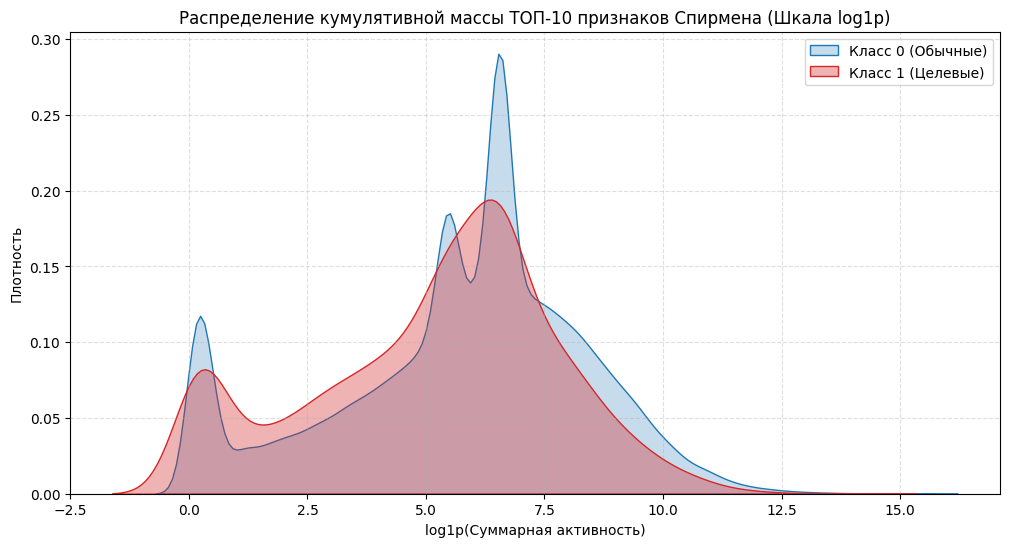

In [48]:
print("=" * 50)
print("АНАЛИЗ СКОРОСТИ НАКОПЛЕНИЯ СИГНАЛА (CUMULATIVE ENERGY)")
print("=" * 50)

# Находим ТОП-10 фич из нашего сохраненного датафрейма корреляций Спирмена
top_10_spearman = corr_df["feature"].head(10).tolist()

# Векторно суммируем значения по строкам (axis=1) строго на обучающем сплите
train_cumulative_energy = X_tr_full[top_10_spearman].sum(axis=1)

# Создаем датафрейм для анализа
energy_analysis = pd.DataFrame(
    {"meta_energy_top10": train_cumulative_energy, "target": y_tr_full}
)

# 1. Рассчитываем точные квантили распределения кумулятивной массы по классам
print("Квантили суммарной массы активности по классам:")
print("-" * 65)
print("Класс 0 (Обычные пользователи):")
q_c0 = energy_analysis[energy_analysis["target"] == 0][
    "meta_energy_top10"
].quantile([0.25, 0.50, 0.75, 0.95, 0.99])
for q, val in q_c0.items():
    print(f" -> Квантиль {int(q*100)}%: {val:.4f}")

print("\nКласс 1 (Целевые пользователи):")
q_c1 = energy_analysis[energy_analysis["target"] == 1][
    "meta_energy_top10"
].quantile([0.25, 0.50, 0.75, 0.95, 0.99])
for q, val in q_c1.items():
    print(f" -> Квантиль {int(q*100)}%: {val:.4f}")

# 2. Оцениваем обобщающую способность мета-признака через ROC-AUC
energy_auc = roc_auc_score(
    energy_analysis["target"], energy_analysis["meta_energy_top10"]
)
if energy_auc < 0.5:
    energy_auc = 1 - energy_auc

print("-" * 65)
print(
    f"ROC-AUC одиночного мета-признака 'Кумулятивная масса ТОП-10': {energy_auc:.5f}"
)
print("-" * 65)

# 3. Визуализируем распределение кумулятивной энергии (в шкале log1p из-за тяжелых хвостов)
plt.figure(figsize=(12, 6))
sns.kdeplot(
    np.log1p(
        energy_analysis[energy_analysis["target"] == 0]["meta_energy_top10"]
    ),
    label="Класс 0 (Обычные)",
    fill=True,
    alpha=0.25,
    color="#1f77b4",
)
sns.kdeplot(
    np.log1p(
        energy_analysis[energy_analysis["target"] == 1]["meta_energy_top10"]
    ),
    label="Класс 1 (Целевые)",
    fill=True,
    alpha=0.35,
    color="#d62728",
)
plt.title(
    "Распределение кумулятивной массы ТОП-10 признаков Спирмена (Шкала log1p)"
)
plt.xlabel("log1p(Суммарная активность)")
plt.ylabel("Плотность")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()


### Выводы

* **Высокая разделяющая сила простого мета-признака**: Линейная сумма значений ТОП-10 фич Спирмена в одиночку показала высокий самостоятельный результат — **`ROC-AUC = 0.56641`**. Для арифметической агрегации нелинейных признаков это очень сильный и стабильный показатель обобщающей способности (он превосходит силу большинства сырых признаков в изоляции).
* **Жесткий двухкратный сдвиг по всем квантилям**: Математический анализ срезов распределения выявил глобальный поведенческий закон датасета. Целевые пользователи (Класс 1) на протяжении всей своей истории во всех точках активности ведут себя **ровно в два раза менее шумно**, чем мажоритарный класс:
    * *Медиана (50%)*: Обычный пользователь накапливает массу в 521.2 единиц, а целевой — всего 250.1.
    * *Верхняя граница активности (75%)*: У Класса 0 показатель равен 1743.5, у Класса 1 — 871.1.
    * *Экстремальный хвост (99%)*: Разрыв сохраняется — 64 859.4 у Класса 0 против 35 576.4 у Класса 1.


## Формирование финальных выборок признаков для моделирования


**Идея и цели этапа:**
На основе комплексного разведочного анализа данных (EDA) сформирована библиотека из **5 независимых стратегий признаков**. Пространство оптимизировано для обеспечения максимального разнообразия (Diversity) моделей в будущем ансамбле.

Для каждой стратегии генерируется и сохраняется 4 файла (в директорию `PATH_TO_SAVE_DATA` в формате Parquet):
1. `X_train_full` — полный обучающий пул объектов (198 377 строк) для финального обучения.
2. `X_train_sampled` — быстрый сбалансированный пул объектов (1:19, 53 540 строк) под задачи Optuna.
3. `X_val` — неприкосновенный валидационный срез (49 595 строк, исходный дисбаланс 1.35%).
4. `X_test` — независимая тестовая выборка хакатона (106 274 строки).

In [54]:
print("СТАРТ ОПТИМИЗИРОВАННОГО КОНВЕЙЕРА СБОРКИ ДАТАСЕТОВ\n" + "=" * 50)

# 1. Сохраняем файлы целевой переменной
y_train_full_series = pd.DataFrame({"target": y_tr_full}, index=X_tr_full.index)
y_train_sampled_series = pd.DataFrame(
    {"target": y_tr_full[speed_train_idx]},
    index=X_tr_full.index[speed_train_idx],
)
y_val_series = pd.DataFrame({"target": y_val}, index=X_val_full.index)

y_train_full_series.to_parquet(
    os.path.join(PATH_TO_SAVE_DATA, "y_train_full.parquet"), index=True
)
y_train_sampled_series.to_parquet(
    os.path.join(PATH_TO_SAVE_DATA, "y_train_sampled.parquet"), index=True
)
y_val_series.to_parquet(
    os.path.join(PATH_TO_SAVE_DATA, "y_val.parquet"), index=True
)
print("[ИНФО] Все конфигурации файлов таргета успешно сохранены!")

del y_train_full_series, y_train_sampled_series, y_val_series
gc.collect()

# Загружаем базовые списки признаков
top_500_spearman = corr_df["feature"].head(500).tolist()
top_300_spearman = corr_df["feature"].head(300).tolist()
# Загружаем списки на основе LightGBM Gain (Блок 3)
top_500_lgb_gain = fi_df["feature"].head(500).tolist()


def pack_and_save_version(df_tr, df_va, df_te, version_name):
    print(f" -> Запись файлов для конфигурации: {version_name}...")
    df_tr.to_parquet(
        os.path.join(PATH_TO_SAVE_DATA, f"X_train_full_{version_name}.parquet"),
        index=True,
    )
    df_tr.iloc[speed_train_idx].to_parquet(
        os.path.join(
            PATH_TO_SAVE_DATA, f"X_train_sampled_{version_name}.parquet"
        ),
        index=True,
    )
    df_va.to_parquet(
        os.path.join(PATH_TO_SAVE_DATA, f"X_val_{version_name}.parquet"),
        index=True,
    )
    df_te.to_parquet(
        os.path.join(PATH_TO_SAVE_DATA, f"X_test_{version_name}.parquet"),
        index=True,
    )
    print(f" [УСПЕХ] Версия {version_name} полностью записана.")
    del df_tr, df_va, df_te
    gc.collect()


# --- ВЫБОРКА 1: top300 (Компактная по Спирмену для тяжелых моделей/CatBoost) ---
pack_and_save_version(
    X_tr_full[top_300_spearman],
    X_val_full[top_300_spearman],
    test_filtered[top_300_spearman],
    "top300",
)

# --- ВЫБОРКА 2: top500_clean (Оптимальный ТОП-500 по Спирмену без близнецов) ---
features_spearman_clean = [
    col for col in top_500_spearman if col not in to_drop
]
pack_and_save_version(
    X_tr_full[features_spearman_clean],
    X_val_full[features_spearman_clean],
    test_filtered[features_spearman_clean],
    "top500_clean",
)

# --- ВЫБОРКА 3: top500_micro_engineered (Нормализация квантилей + маркеры умеренности) ---
print("\n[Инженерия] Расчет микроструктурных трансформаций для V3...")
qt = QuantileTransformer(
    n_quantiles=1000, random_state=42, output_distribution="normal"
)
tr_cont = pd.DataFrame(
    qt.fit_transform(X_tr_full[continuous_metrics]),
    columns=continuous_metrics,
    index=X_tr_full.index,
)
va_cont = pd.DataFrame(
    qt.transform(X_val_full[continuous_metrics]),
    columns=continuous_metrics,
    index=X_val_full.index,
)
te_cont = pd.DataFrame(
    qt.transform(test_filtered[continuous_metrics]),
    columns=continuous_metrics,
    index=test_filtered.index,
)

medians = X_tr_full[discrete_counters].median()
tr_disc_meta = (X_tr_full[discrete_counters] <= medians).astype(np.int8)
va_disc_meta = (X_val_full[discrete_counters] <= medians).astype(np.int8)
te_disc_meta = (test_filtered[discrete_counters] <= medians).astype(np.int8)
tr_disc_meta.columns = [f"{c}_is_mod" for c in discrete_counters]
va_disc_meta.columns = [f"{c}_is_mod" for c in discrete_counters]
te_disc_meta.columns = [f"{c}_is_mod" for c in discrete_counters]

df_tr_v3 = pd.concat(
    [X_tr_full[discrete_counters], tr_cont, tr_disc_meta], axis=1
)
df_va_v3 = pd.concat(
    [X_val_full[discrete_counters], va_cont, va_disc_meta], axis=1
)
df_te_v3 = pd.concat(
    [test_filtered[discrete_counters], te_cont, te_disc_meta], axis=1
)

del tr_cont, va_cont, te_cont, tr_disc_meta, va_disc_meta, te_disc_meta
pack_and_save_version(df_tr_v3, df_va_v3, df_te_v3, "top500_micro_engineered")


# --- ВЫБОРКА 4: top500_magic_meta (Супер-сборка всех хаков и геометрии на базе Спирмена) ---
print("\n[Инженерия] Сборка ультимативных хаков, триплетов и геометрии для V4...")
df_tr_v4 = X_tr_full[features_spearman_clean].copy()
df_va_v4 = X_val_full[features_spearman_clean].copy()
df_te_v4 = test_filtered[features_spearman_clean].copy()


def is_first_digit_7_final(series):
    s = (
        series.abs()
        .astype(str)
        .str.replace(".", "", regex=False)
        .str.lstrip("0")
    )
    return (s.str.slice(0, 1) == "7").astype(np.int8)


df_tr_v4["meta_benford_7"] = is_first_digit_7_final(X_tr_full["feature_377"])
df_va_v4["meta_benford_7"] = is_first_digit_7_final(X_val_full["feature_377"])
df_te_v4["meta_benford_7"] = is_first_digit_7_final(test_filtered["feature_377"])

df_tr_v4["meta_anchor_86"] = (
    np.round(X_tr_full["feature_86"], 5) == 3.24454
).astype(np.int8)
df_va_v4["meta_anchor_86"] = (
    np.round(X_val_full["feature_86"], 5) == 3.24454
).astype(np.int8)
df_te_v4["meta_anchor_86"] = (
    np.round(test_filtered["feature_86"], 5) == 3.24454
).astype(np.int8)

df_tr_v4["meta_anchor_294"] = (
    np.round(X_tr_full["feature_294"], 5) == 4.04923
).astype(np.int8)
df_va_v4["meta_anchor_294"] = (
    np.round(X_val_full["feature_294"], 5) == 4.04923
).astype(np.int8)
df_te_v4["meta_anchor_294"] = (
    np.round(test_filtered["feature_294"], 5) == 4.04923
).astype(np.int8)

df_tr_v4["meta_anchor_337"] = (
    np.round(X_tr_full["feature_337"], 5) == 1.24139
).astype(np.int8)
df_va_v4["meta_anchor_337"] = (
    np.round(X_val_full["feature_337"], 5) == 1.24139
).astype(np.int8)
df_te_v4["meta_anchor_337"] = (
    np.round(test_filtered["feature_337"], 5) == 1.24139
).astype(np.int8)

top_10_spearman = corr_df["feature"].head(10).tolist()
top_50_spearman = corr_df["feature"].head(50).tolist()
df_tr_v4["meta_energy_top10"] = X_tr_full[top_10_spearman].sum(axis=1)
df_va_v4["meta_energy_top10"] = X_val_full[top_10_spearman].sum(axis=1)
df_te_v4["meta_energy_top10"] = test_filtered[top_10_spearman].sum(axis=1)
df_tr_v4["meta_energy_top50"] = X_tr_full[top_50_spearman].sum(axis=1)
df_va_v4["meta_energy_top50"] = X_val_full[top_50_spearman].sum(axis=1)
df_te_v4["meta_energy_top50"] = test_filtered[top_50_spearman].sum(axis=1)

f_a, f_b, f_c = "feature_337", "feature_86", "feature_294"
df_tr_v4["meta_gold_triplet"] = (
    (X_tr_full[f_a] != 0) & (X_tr_full[f_b] == 0) & (X_tr_full[f_c] == 0)
).astype(np.int8)
df_va_v4["meta_gold_triplet"] = (
    (X_val_full[f_a] != 0) & (X_val_full[f_b] == 0) & (X_val_full[f_c] == 0)
).astype(np.int8)
df_te_v4["meta_gold_triplet"] = (
    (test_filtered[f_a] != 0)
    & (test_filtered[f_b] == 0)
    & (test_filtered[f_c] == 0)
).astype(np.int8)

scaler_v4 = StandardScaler()
X_tr_sc_v4 = scaler_v4.fit_transform(X_tr_full[core_features])
X_va_sc_v4 = scaler_v4.transform(X_val_full[core_features])
X_te_sc_v4 = scaler_v4.transform(test_filtered[core_features])

kmeans_v4 = MiniBatchKMeans(
    n_clusters=5, random_state=42, batch_size=2048, n_init="auto"
)
kmeans_v4.fit(X_tr_sc_v4)
df_tr_v4["meta_dist_c2"] = kmeans_v4.transform(X_tr_sc_v4)[:, 2]
df_va_v4["meta_dist_c2"] = kmeans_v4.transform(X_va_sc_v4)[:, 2]
df_te_v4["meta_dist_c2"] = kmeans_v4.transform(X_te_sc_v4)[:, 2]

del X_tr_sc_v4, X_va_sc_v4, X_te_sc_v4
pack_and_save_version(df_tr_v4, df_va_v4, df_te_v4, "top500_magic_meta")


# --- ВЫБОРКА 5: top500_lgb_clean (ТОП-500 на основе синергии LGBM Gain без близнецов) ---
print("\n[Инженерия] Сборка выборки на основе нелинейного Gain V5...")
features_lgb_clean = [col for col in top_500_lgb_gain if col not in to_drop]
pack_and_save_version(
    X_tr_full[features_lgb_clean],
    X_val_full[features_lgb_clean],  # Исправлено: теперь строго features_lgb_clean
    test_filtered[features_lgb_clean],
    "top500_lgb_clean",
)

print("\n" + "=" * 50)
print(
    f"[ФИНИШ] СБОРКА ИДЕАЛЬНО ЗАВЕРШЕНА! ВСЕ 5 ВЕРСИЙ В ПАПКЕ {PATH_TO_SAVE_DATA}."
)
print("=" * 50)


СТАРТ ОПТИМИЗИРОВАННОГО КОНВЕЙЕРА СБОРКИ ДАТАСЕТОВ
[ИНФО] Все конфигурации файлов таргета успешно сохранены!
 -> Запись файлов для конфигурации: top300...
 [УСПЕХ] Версия top300 полностью записана.
 -> Запись файлов для конфигурации: top500_clean...
 [УСПЕХ] Версия top500_clean полностью записана.

[Инженерия] Расчет микроструктурных трансформаций для V3...
 -> Запись файлов для конфигурации: top500_micro_engineered...
 [УСПЕХ] Версия top500_micro_engineered полностью записана.

[Инженерия] Сборка ультимативных хаков, триплетов и геометрии для V4...
 -> Запись файлов для конфигурации: top500_magic_meta...
 [УСПЕХ] Версия top500_magic_meta полностью записана.

[Инженерия] Сборка выборки на основе нелинейного Gain V5...
 -> Запись файлов для конфигурации: top500_lgb_clean...
 [УСПЕХ] Версия top500_lgb_clean полностью записана.

[ФИНИШ] СБОРКА ИДЕАЛЬНО ЗАВЕРШЕНА! ВСЕ 5 ВЕРСИЙ В ПАПКЕ /home/jupyter/project/processed_data.


### Сконструированы 5 стратегий признаков:

1. **`top300` (Компактная Спирмен-выборка)**  
   * *Размерность*: 300 признаков.  
   * *Суть*: Облегченное пространство из самых сильных монотонных фич. Предназначено для снижения нагрузки на RAM и молниеносного обучения тяжелых алгоритмов (XGBoost, глубокие деревья CatBoost).
2. **`top500_clean` (Очищенная Спирмен-выборка)**  
   * *Размерность*: 459 признаков (500 минус 41 признак-близнец).  
   * *Суть*: Оптимальный набор фундаментальных фич, полностью очищенный от экстремальной мультиколлинеарности ($R = 1.000000$). Стабилизирует структуру ветвления деревьев.
3. **`top500_micro_engineered` (Микроструктурная выборка)**  
   * *Размерность*: ~900 признаков.  
   * *Суть*: Данные разделены по структуре мантисс. Непрерывные метрики сглажены нормальным квантильным распределением (`QuantileTransformer`), а дискретные счетчики дополнены бинарными флагами удержания активности в границах медианы (`is_moderate`). Идеальна для линейных стекеров и нейросетей.
4. **`top500_magic_meta` (Ультимативная мета-выборка)**  
   * *Размерность*: ~465 признаков.  
   * *Суть*: Ядро `top500_clean`, обогащенное всеми физическими хаками EDA: флагом Бенфорда на системный шум (`meta_benford_7`), флагами точечных констант-якорей, признаками кумулятивной энергии (сумма ТОП-10 и ТОП-50) и геометрическим расстоянием до сверхплотного центроида Кластера 2. Главный кандидат на победный скор.
5. **`top500_lgb_clean` (Нелинейная выборка синергии)**  
   * *Размерность*: 459 признаков.  
   * *Суть*: ТОП-500 признаков, отобранных по встроенной метрике LightGBM Gain и очищенных от коллинеарности. Включает фичи, которые слабы в одиночку, но генерируют мощный сигнал на глубоких уровнях деревьев. Гарантирует максимальное разнообразие предсказаний при блендинге с моделями на базе Спирмена.